In [1]:
# Naive Bayes

### Set Up

In [2]:
# install required packages
import requests
import pandas as pd
import json
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.cm as cm

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, scale
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, silhouette_samples

from sklearn.tree import plot_tree

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, recall_score

from sklearn import decomposition #PCA

from itertools import cycle, islice

from pandas.plotting import parallel_coordinates

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster






### National Park Service Data

#### National Park Service Sites

In [3]:
# National Park Service API Set Up
nps_url_base = "developer.nps.gov/api/v1"

my_api_key = 'your_key_here'

nps_url_request = "https://developer.nps.gov/api/v1/parks?limit=500&get=designation,fullName,id,name,parkCode,states&for=parkCode:*&api_key=" + my_api_key

# need to update limit to 500 for full run

In [4]:
# Execute API request
response = requests.get(nps_url_request)

In [5]:
# Check status of API request, report status, and if good transform data into dataframe and print column names
if response.status_code == 200:
    print('Successful API download')
    nps_api_exp = json.loads(response.text)
    nps_data = pd.DataFrame(nps_api_exp['data'])
    print(nps_data.columns)
else: print(f'API download failed. Error code: {response.status_code}')

Successful API download
Index(['id', 'url', 'fullName', 'parkCode', 'description', 'latitude',
       'longitude', 'latLong', 'activities', 'topics', 'states', 'contacts',
       'entranceFees', 'entrancePasses', 'fees', 'directionsInfo',
       'directionsUrl', 'operatingHours', 'addresses', 'images', 'weatherInfo',
       'name', 'designation', 'multimedia', 'relevanceScore'],
      dtype='str')


In [6]:
# Select parameters of interest from API data set
nps_sites0 = nps_data[['fullName','name','parkCode','designation','states']]

# Rename columns
nps_sites0 = nps_sites0.rename(columns={'fullName': 'Site_Full_Name', 'name': 'Site_Name', 'parkCode': 'Park_Code', 'designation': 'Designation', 'states': 'State List'})

# Capitalize park code for consistent formatting
nps_sites0['Park_Code'] = nps_sites0['Park_Code'].str.upper()

#nps_sites.head()

In [7]:
nps_sites_nodesig = nps_sites0[nps_sites0['Designation']==""]
nps_sites_nodesig

nps_sites_nodesig['Designation'] = 'Undesignated'

#nps_sites_nodesig

In [8]:
nps_sites_desig = nps_sites0[nps_sites0['Designation']!=""]
nps_sites_desig

,Site_Full_Name,Site_Name,Park_Code,Designation,State List
0,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,ABLI,National Historical Park,KY
1,Acadia National Park,Acadia,ACAD,National Park,ME
2,Adams National Historical Park,Adams,ADAM,National Historical Park,MA
4,African Burial Ground National Monument,African Burial Ground,AFBG,National Monument,NY
5,Agate Fossil Beds National Monument,Agate Fossil Beds,AGFO,National Monument,NE
...,...,...,...,...,...
469,Yorktown Battlefield Part of Colonial National...,Yorktown Battlefield,YORK,Part of Colonial National Historical Park,VA
470,Yosemite National Park,Yosemite,YOSE,National Park,CA
471,Yucca House National Monument,Yucca House,YUHO,National Monument,CO
472,Yukon - Charley Rivers National Preserve,Yukon - Charley Rivers,YUCH,National Preserve,AK


In [9]:
nps_sites = pd.concat([nps_sites_desig, nps_sites_nodesig], ignore_index = True)
nps_sites.sort_values(by = 'Park_Code')
nps_sites.head()

,Site_Full_Name,Site_Name,Park_Code,Designation,State List
0,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,ABLI,National Historical Park,KY
1,Acadia National Park,Acadia,ACAD,National Park,ME
2,Adams National Historical Park,Adams,ADAM,National Historical Park,MA
3,African Burial Ground National Monument,African Burial Ground,AFBG,National Monument,NY
4,Agate Fossil Beds National Monument,Agate Fossil Beds,AGFO,National Monument,NE


In [10]:
# Break out list of sites by individual states
# (will include duplicate listings for parks spanning multiple states)
#nps_sites_state = nps_sites[['Park_Code','State List','Designation']]

#nps_sites_state['State Abb'] = nps_sites['State List']

#nps_sites_state['State Abb'] = (nps_sites_state['State List'].str.split(','))

#nps_sites_state = nps_sites_state.explode('State Abb')

#nps_sites_state = nps_sites_state.reset_index(drop=True)

#### Visitor Data

In [11]:
# Visitation Data

visit_file_1 = "Data/Annual Visitation By Park (1979-1985).csv"

visit_1_load = pd.read_csv(visit_file_1)

#visit_1_load.head(10)

visit_1_load.columns = visit_1_load.iloc[5]

visit_1_load = visit_1_load.iloc[6:].reset_index(drop = True)

visit_1 = visit_1_load.drop(visit_1_load.columns[[0,9,10,11]], axis=1)

#visit_1.head(10)

# Convert from pivot table to flat table format

visit_1_fl = visit_1.set_index('Park Name').stack().reset_index()

visit_1_fl.rename(columns={5: "Year", 0: "Visitors"}, inplace=True)

#visit_1_fl.head(10)

visit_file_2 = "Data/Annual Visitation By Park (1986-2006).csv"

visit_2_load = pd.read_csv(visit_file_2)

#visit_2_load.head(10)

visit_2_load.columns = visit_2_load.iloc[5]

visit_2_load = visit_2_load.iloc[6:].reset_index(drop = True)

#visit_2_load.head(10)

visit_2 = visit_2_load.drop(visit_2_load.columns[[0,11,12,24]], axis=1)

#visit_2.head(10)

# Convert from pivot table to flat table format

visit_2_fl = visit_2.set_index('Park Name').stack().reset_index()

visit_2_fl.rename(columns={5: "Year", 0: "Visitors"}, inplace=True)

#visit_2_fl.head()

visit_file_3 = "Data/Annual Visitation By Park (2006-2025).csv"

visit_3_load = pd.read_csv(visit_file_3)

#visit_3_load.head(10)

visit_3_load.columns = visit_3_load.iloc[5]

visit_3_load = visit_3_load.iloc[6:].reset_index(drop = True)

#visit_3_load.head(10)

visit_3 = visit_3_load.drop(visit_3_load.columns[[0,11,12,24]], axis=1)

#visit_3.head(10)

# Convert from pivot table to flat table format

visit_3_fl = visit_3.set_index('Park Name').stack().reset_index()

visit_3_fl.rename(columns={5: "Year", 0: "Visitors"}, inplace=True)

#visit_3_fl.head()

In [12]:
# Concatenate Visitor Totals from Tables

visitors = pd.concat([visit_1_fl, visit_2_fl, visit_3_fl], ignore_index=True)

visitors = visitors.sort_values(by=['Park Name','Year'])

visitors.head()

#print(visitors.shape)

,Park Name,Year,Visitors
0,Abraham Lincoln Birthplace NHP,1979,"271,231"
1,Abraham Lincoln Birthplace NHP,1980,"239,074"
2,Abraham Lincoln Birthplace NHP,1981,"252,245"
3,Abraham Lincoln Birthplace NHP,1982,"318,707"
4,Abraham Lincoln Birthplace NHP,1983,"256,126"


In [13]:
# Remove any rows without park name
visitors.dropna(subset = ['Park Name'], inplace = True)

#print(visitors.shape)

# Convert numbers strings to numbers
visitors['Visitors'] = visitors['Visitors'].str.replace(",","")

visitors['Visitors'] = pd.to_numeric(visitors['Visitors'])
visitors['Year'] = pd.to_numeric(visitors['Year'])

# Remove entries with no visitor numbers
visitors['Visitors'] = visitors['Visitors'].dropna()
#visitors['Visitors Scaled'] = visitors['Visitors Scaled'].fillna(0)

#visitors['Visitors'].dtype


In [14]:
# Scale visitor numbers

vis_max = max(visitors['Visitors'])

visitors['Visitors Scaled'] = visitors['Visitors']/vis_max

In [15]:
# Import list of Site Abbreviations

visit_abb_file = "Data/Visitor_Sites_Codes.csv"

visitor_park_abb_load = pd.read_csv(visit_abb_file)

#visitor_park_abb_load.head()

visitor_park_abb = visitor_park_abb_load[['Park Name','Park_Code']]

#visitor_park_abb.head()

# Join site abbreviations to data frame

visitors = pd.merge(visitors, visitor_park_abb, on='Park Name', how='left')

visitors['Code_Year'] = visitors['Park_Code'] + '-' + visitors['Year'].astype(str)

visitors.head()

,Park Name,Year,Visitors,Visitors Scaled,Park_Code,Code_Year
0,Abraham Lincoln Birthplace NHP,1979,271231.0,0.012461,ABLI,ABLI-1979
1,Abraham Lincoln Birthplace NHP,1980,239074.0,0.010983,ABLI,ABLI-1980
2,Abraham Lincoln Birthplace NHP,1981,252245.0,0.011588,ABLI,ABLI-1981
3,Abraham Lincoln Birthplace NHP,1982,318707.0,0.014642,ABLI,ABLI-1982
4,Abraham Lincoln Birthplace NHP,1983,256126.0,0.011767,ABLI,ABLI-1983


In [16]:
visitors.describe()

,Year,Visitors,Visitors Scaled
count,17247.000000,1.609500e+04,16095.000000
mean,2003.127732,8.044333e+05,0.036956
std,13.390632,1.781894e+06,0.081862
min,1979.000000,0.000000e+00,0.000000
25%,1992.000000,5.174150e+04,0.002377
50%,2004.000000,2.053870e+05,0.009436
75%,2015.000000,7.563200e+05,0.034746
max,2025.000000,2.176718e+07,1.000000


In [17]:
#sel1 = visitors[(visitors['annual_chg_pct']<-0.9) & (visitors['annual_chg_pct']>-10)]
#sel1
#sns.countplot(data = visitors, x = 'annual_chg_pct')
#plt.show()

In [18]:
look = visitors[visitors['Visitors'] == 0]
look

,Park Name,Year,Visitors,Visitors Scaled,Park_Code,Code_Year
492,Aniakchak NM & PRES,1995,0.0,0.0,ANIA,ANIA-1995
818,Arlington House The R.E. Lee MEM,2019,0.0,0.0,ARHO,ARHO-2019
819,Arlington House The R.E. Lee MEM,2020,0.0,0.0,ARHO,ARHO-2020
1028,Belmont-Paul Women's Equality NM,2021,0.0,0.0,BEPA,BEPA-2021
1029,Belmont-Paul Women's Equality NM,2022,0.0,0.0,BEPA,BEPA-2022
2281,Cape Krusenstern NM,2014,0.0,0.0,CAKR,CAKR-2014
2282,Cape Krusenstern NM,2015,0.0,0.0,CAKR,CAKR-2015
2543,Carter G. Woodson Home NHS,2021,0.0,0.0,CAWO,CAWO-2021
2544,Carter G. Woodson Home NHS,2022,0.0,0.0,CAWO,CAWO-2022
2545,Carter G. Woodson Home NHS,2023,0.0,0.0,CAWO,CAWO-2023


In [19]:
viz0 = visitors[visitors['Visitors'] == 0]
viz0.shape

(54, 6)

In [20]:
# Calculate the change in annual visitor numbers from previous year 

# check to see if previous row is from same park
visitors['site_chk'] = (visitors['Park_Code'] == visitors['Park_Code'].shift(1)).astype(int)

# calculate the difference (whole and percentage) of visitors from the previous year (for the same site)
visitors['annual_chg'] = (visitors['Visitors'].diff()) * visitors['site_chk']
visitors['annual_chg_pct'] = (visitors['Visitors'].diff()) * visitors['site_chk'] / visitors['Visitors'].shift(1)

# replace infinite values with 15
visitors['annual_chg_pct'] = visitors['annual_chg_pct'].replace(np.inf, 15)


In [21]:
visitors.head()

,Park Name,Year,Visitors,Visitors Scaled,Park_Code,Code_Year,site_chk,annual_chg,annual_chg_pct
0,Abraham Lincoln Birthplace NHP,1979,271231.0,0.012461,ABLI,ABLI-1979,0,NaN,NaN
1,Abraham Lincoln Birthplace NHP,1980,239074.0,0.010983,ABLI,ABLI-1980,1,-32157.0,-0.118559
2,Abraham Lincoln Birthplace NHP,1981,252245.0,0.011588,ABLI,ABLI-1981,1,13171.0,0.055092
3,Abraham Lincoln Birthplace NHP,1982,318707.0,0.014642,ABLI,ABLI-1982,1,66462.0,0.263482
4,Abraham Lincoln Birthplace NHP,1983,256126.0,0.011767,ABLI,ABLI-1983,1,-62581.0,-0.196359


In [22]:
# remove the years with no previous year to track change
visitors = visitors[abs(visitors['annual_chg_pct']) > 0]
visitors.head()

,Park Name,Year,Visitors,Visitors Scaled,Park_Code,Code_Year,site_chk,annual_chg,annual_chg_pct
1,Abraham Lincoln Birthplace NHP,1980,239074.0,0.010983,ABLI,ABLI-1980,1,-32157.0,-0.118559
2,Abraham Lincoln Birthplace NHP,1981,252245.0,0.011588,ABLI,ABLI-1981,1,13171.0,0.055092
3,Abraham Lincoln Birthplace NHP,1982,318707.0,0.014642,ABLI,ABLI-1982,1,66462.0,0.263482
4,Abraham Lincoln Birthplace NHP,1983,256126.0,0.011767,ABLI,ABLI-1983,1,-62581.0,-0.196359
5,Abraham Lincoln Birthplace NHP,1984,258023.0,0.011854,ABLI,ABLI-1984,1,1897.0,0.007407


In [23]:
visitors[visitors['Visitors']==0]

,Park Name,Year,Visitors,Visitors Scaled,Park_Code,Code_Year,site_chk,annual_chg,annual_chg_pct
492,Aniakchak NM & PRES,1995,0.0,0.0,ANIA,ANIA-1995,1,-1193.0,-1.0
818,Arlington House The R.E. Lee MEM,2019,0.0,0.0,ARHO,ARHO-2019,1,-49500.0,-1.0
1028,Belmont-Paul Women's Equality NM,2021,0.0,0.0,BEPA,BEPA-2021,1,-2535.0,-1.0
2281,Cape Krusenstern NM,2014,0.0,0.0,CAKR,CAKR-2014,1,-18225.0,-1.0
2543,Carter G. Woodson Home NHS,2021,0.0,0.0,CAWO,CAWO-2021,1,-548.0,-1.0
3363,Clara Barton NHS,2016,0.0,0.0,CLBA,CLBA-2016,1,-2823.0,-1.0
3368,Clara Barton NHS,2021,0.0,0.0,CLBA,CLBA-2021,1,-450.0,-1.0
4368,Edgar Allan Poe NHS,2021,0.0,0.0,EDAL,EDAL-2021,1,-2418.0,-1.0
4372,Edgar Allan Poe NHS,2025,0.0,0.0,EDAL,EDAL-2025,1,-8131.0,-1.0
4741,Federal Hall NMEM,2005,0.0,0.0,FEHA,FEHA-2005,1,-156707.0,-1.0


In [24]:
# simplify data frame for merging
visitors_sel = visitors[['Park_Code','Code_Year','Year','Visitors','Visitors Scaled','annual_chg','annual_chg_pct']]
visitors_sel.head()

,Park_Code,Code_Year,Year,Visitors,Visitors Scaled,annual_chg,annual_chg_pct
1,ABLI,ABLI-1980,1980,239074.0,0.010983,-32157.0,-0.118559
2,ABLI,ABLI-1981,1981,252245.0,0.011588,13171.0,0.055092
3,ABLI,ABLI-1982,1982,318707.0,0.014642,66462.0,0.263482
4,ABLI,ABLI-1983,1983,256126.0,0.011767,-62581.0,-0.196359
5,ABLI,ABLI-1984,1984,258023.0,0.011854,1897.0,0.007407


In [25]:
high_vpct = visitors_sel[visitors_sel['annual_chg_pct'] > 10]

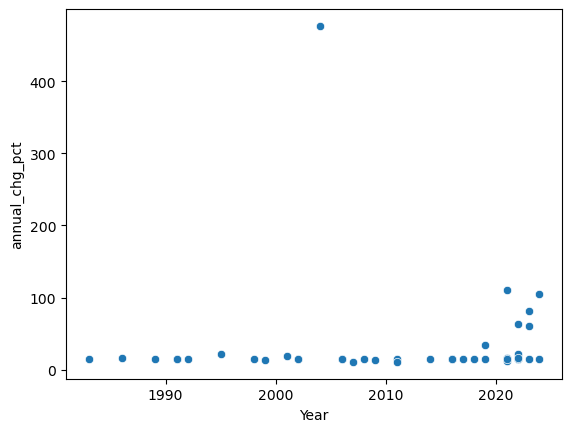

In [26]:
sns.scatterplot(data = high_vpct, x = 'Year', y = 'annual_chg_pct')
plt.show()

In [27]:
inf_chk0 = visitors[np.isinf(visitors['annual_chg_pct'])]
inf_chk0

,Park Name,Year,Visitors,Visitors Scaled,Park_Code,Code_Year,site_chk,annual_chg,annual_chg_pct


In [28]:
# Add designation to data frame for additional filtering
# designation list
nps_sites_desiglist = nps_sites[['Park_Code','Designation']]

visitor_park_wdesig = pd.merge(visitor_park_abb,nps_sites_desiglist,on = 'Park_Code', how = 'left')

visitor_park_wdesig.drop(columns=['Park Name'], inplace=True)

visitor_park_wdesig.head()


,Park_Code,Designation
0,ABLI,National Historical Park
1,ACAD,National Park
2,ADAM,National Historical Park
3,AFBG,National Monument
4,AGFO,National Monument


#### National Park Service Traffic

In [29]:
# Traffic Data

traffic_file_1 = "Data/Query Builder for Traffic Counts (1985-1989).csv"

traffic_file_2 = "Data/Query Builder for Traffic Counts (1990-1999).csv"

traffic_file_3 = "Data/Query Builder for Traffic Counts (2000-2009).csv"

traffic_file_4 = "Data/Query Builder for Traffic Counts (2010-2019).csv"

traffic_file_5 = "Data/Query Builder for Traffic Counts (2020-2025).csv"

In [30]:
# Load traffic data
traffic_1_load = pd.read_csv(traffic_file_1)

#traffic_1_load.head(10)

traffic_1_load.columns = traffic_1_load.iloc[1]

traffic_1_load = traffic_1_load.iloc[2:].reset_index(drop = True)

traffic_1 = traffic_1_load[[]]

#traffic_1_load.head(10)

#traffic_1_load['Traffic Count'].dtype

traffic_1_load['Traffic Count'] = traffic_1_load['Traffic Count'].str.replace(",","")

#traffic_1_load.head()

traffic_1_load['Traffic Count'] = pd.to_numeric(traffic_1_load['Traffic Count'])

traffic_1_load['Unit Code'] = traffic_1_load['Unit Code'].replace({'FOCA': 'TIMU', 'JODR': 'GRTE', 'KICA': 'SEKI', 'SEQU': 'SEKI', 'NCPE': 'NACE', 'OBRI': 'OBED', 'ROLA':'NOCA'})


#traffic_1_load['Traffic Count'].dtype

#traffic_1_load.head()

traffic_1 = traffic_1_load.groupby(['Unit Code','Year'])['Traffic Count'].sum().reset_index()

#traffic_1

#

traffic_2_load = pd.read_csv(traffic_file_2)

#traffic_2_load.head(10)

traffic_2_load.columns = traffic_2_load.iloc[1]

traffic_2_load = traffic_2_load.iloc[2:].reset_index(drop = True)

traffic_2 = traffic_2_load[[]]

#traffic_2_load.head(10)

#traffic_2_load['Traffic Count'].dtype

traffic_2_load['Traffic Count'] = traffic_2_load['Traffic Count'].str.replace(",","")

#traffic_2_load.head()

traffic_2_load['Traffic Count'] = pd.to_numeric(traffic_2_load['Traffic Count'])

traffic_2_load['Unit Code'] = traffic_2_load['Unit Code'].replace({'FOCA': 'TIMU', 'JODR': 'GRTE', 'KICA': 'SEKI', 'SEQU': 'SEKI', 'NCPE': 'NACE', 'OBRI': 'OBED', 'ROLA':'NOCA'})


#traffic_2_load['Traffic Count'].dtype

#traffic_2_load.head()

traffic_2 = traffic_2_load.groupby(['Unit Code','Year'])['Traffic Count'].sum().reset_index()

#traffic_2

#

traffic_3_load = pd.read_csv(traffic_file_3)

#traffic_3_load.head(10)

traffic_3_load.columns = traffic_3_load.iloc[1]

traffic_3_load = traffic_3_load.iloc[2:].reset_index(drop = True)

traffic_3 = traffic_3_load[[]]

#traffic_3_load.head(10)

#traffic_3_load['Traffic Count'].dtype

traffic_3_load['Traffic Count'] = traffic_3_load['Traffic Count'].str.replace(",","")

#traffic_3_load.head()

traffic_3_load['Traffic Count'] = pd.to_numeric(traffic_3_load['Traffic Count'])

traffic_3_load['Unit Code'] = traffic_3_load['Unit Code'].replace({'FOCA': 'TIMU', 'JODR': 'GRTE', 'KICA': 'SEKI', 'SEQU': 'SEKI', 'NCPE': 'NACE', 'OBRI': 'OBED', 'ROLA':'NOCA'})


#traffic_3_load['Traffic Count'].dtype

#traffic_3_load.head()

traffic_3 = traffic_3_load.groupby(['Unit Code','Year'])['Traffic Count'].sum().reset_index()

#traffic_3

#

traffic_4_load = pd.read_csv(traffic_file_4)

#traffic_4_load.head(10)

traffic_4_load.columns = traffic_4_load.iloc[1]

traffic_4_load = traffic_4_load.iloc[2:].reset_index(drop = True)

traffic_4 = traffic_4_load[[]]

#traffic_4_load.head(10)

#traffic_4_load['Traffic Count'].dtype

traffic_4_load['Traffic Count'] = traffic_4_load['Traffic Count'].str.replace(",","")

#traffic_4_load.head()

traffic_4_load['Traffic Count'] = pd.to_numeric(traffic_4_load['Traffic Count'])

traffic_4_load['Unit Code'] = traffic_4_load['Unit Code'].replace({'FOCA': 'TIMU', 'JODR': 'GRTE', 'KICA': 'SEKI', 'SEQU': 'SEKI', 'NCPE': 'NACE', 'OBRI': 'OBED', 'ROLA':'NOCA'})


traffic_4_load['Traffic Count'].dtype

#traffic_4_load.head()

traffic_4 = traffic_4_load.groupby(['Unit Code','Year'])['Traffic Count'].sum().reset_index()

#traffic_4

#

traffic_5_load = pd.read_csv(traffic_file_5)

traffic_5_load.columns = traffic_5_load.iloc[1]

traffic_5_load = traffic_5_load.iloc[2:].reset_index(drop = True)

traffic_5 = traffic_5_load[[]]

traffic_5_load['Traffic Count'] = traffic_5_load['Traffic Count'].str.replace(",","")

#traffic_5_load.head()

traffic_5_load['Traffic Count'] = pd.to_numeric(traffic_5_load['Traffic Count'])

traffic_5_load['Unit Code'] = traffic_5_load['Unit Code'].replace({'FOCA': 'TIMU', 'JODR': 'GRTE', 'KICA': 'SEKI', 'SEQU': 'SEKI', 'NCPE': 'NACE', 'OBRI': 'OBED', 'ROLA':'NOCA'})


traffic_5 = traffic_5_load.groupby(['Unit Code','Year'])['Traffic Count'].sum().reset_index()


In [31]:
# Concatenate Traffic Totals from Tables

traffic = pd.concat([traffic_1,traffic_2,traffic_3,traffic_4,traffic_5], ignore_index=True)


In [32]:
traffic.head()

,Unit Code,Year,Traffic Count
0,BLRI,1988,3721649.0
1,BLRI,1989,3891985.0
2,YOSE,1985,1571341.0
3,YOSE,1986,1370764.0
4,YOSE,1987,1621929.0


In [33]:

traffic['Year'] = pd.to_numeric(traffic['Year'])

#traffic['Unit Code'] = df['Unit Code'].replace({'FOCA': 'TIMU', 'JODR': 'GRTE', 'KICA': 'SEKI', 'SEQU': 'SEKI', 'NCPE': 'NACE', 'OBRI': 'OBED', 'ROLA':'NOCA'})

traffic['Code_Year'] = traffic['Unit Code'] + '-' + traffic['Year'].astype(str)

traffic_max = max(traffic['Traffic Count'])

traffic['Traffic Count Scaled'] = traffic['Traffic Count']/traffic_max

traffic = traffic.rename(columns={'Unit Code': 'Park_Code'})

traffic = traffic.sort_values(by='Code_Year')

print(traffic.head(10))

print(traffic.shape)

     Park_Code  Year  Traffic Count  Code_Year  Traffic Count Scaled
7         ABLI  1993        84248.0  ABLI-1993              0.002412
8         ABLI  1994        78659.0  ABLI-1994              0.002252
9         ABLI  1995        75253.0  ABLI-1995              0.002154
10        ABLI  1996        69894.0  ABLI-1996              0.002001
11        ABLI  1997        73586.0  ABLI-1997              0.002106
12        ABLI  1998        70560.0  ABLI-1998              0.002020
13        ABLI  1999        70798.0  ABLI-1999              0.002027
1414      ABLI  2000        67485.0  ABLI-2000              0.001932
1415      ABLI  2001        65934.0  ABLI-2001              0.001887
1416      ABLI  2002        94503.0  ABLI-2002              0.002705
(6703, 5)


In [34]:
traffic.describe()

,Year,Traffic Count,Traffic Count Scaled
count,6703.000000,6.703000e+03,6703.000000
mean,2009.135611,9.601209e+05,0.027482
std,9.757701,3.171714e+06,0.090787
min,1985.000000,-2.633245e+06,-0.075374
25%,2001.000000,4.961450e+04,0.001420
50%,2009.000000,1.731410e+05,0.004956
75%,2018.000000,4.856385e+05,0.013901
max,2025.000000,3.493576e+07,1.000000


In [35]:
traffic['Traffic Count'] = traffic['Traffic Count'].abs()
traffic['Traffic Count Scaled'] = traffic['Traffic Count Scaled'].abs()

In [36]:
traffic[traffic['Traffic Count'] < 0]

,Park_Code,Year,Traffic Count,Code_Year,Traffic Count Scaled


In [37]:
traffic.describe()

,Year,Traffic Count,Traffic Count Scaled
count,6703.000000,6.703000e+03,6703.000000
mean,2009.135611,9.609398e+05,0.027506
std,9.757701,3.171465e+06,0.090780
min,1985.000000,0.000000e+00,0.000000
25%,2001.000000,4.967150e+04,0.001422
50%,2009.000000,1.731710e+05,0.004957
75%,2018.000000,4.859310e+05,0.013909
max,2025.000000,3.493576e+07,1.000000


In [38]:
traffic.info()

<class 'pandas.DataFrame'>
Index: 6703 entries, 7 to 6702
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Park_Code             6703 non-null   str    
 1   Year                  6703 non-null   int64  
 2   Traffic Count         6703 non-null   float64
 3   Code_Year             6703 non-null   str    
 4   Traffic Count Scaled  6703 non-null   float64
dtypes: float64(2), int64(1), str(2)
memory usage: 400.9 KB


In [39]:
# Calculate the change in annual visitor numbers from previous year 

# check to see if previous row is from same park
traffic['site_chk'] = (traffic['Park_Code'] == traffic['Park_Code'].shift(1)).astype(int)

# calculate the difference (whole and percentage) of visitors from the previous year (for the same site)
traffic['annual_chg'] = (traffic['Traffic Count'].diff()) * traffic['site_chk']
traffic['annual_chg_pct'] = (traffic['Traffic Count'].diff()) * traffic['site_chk'] / traffic['Traffic Count'].shift(1)

# replace infinite values with 15 
traffic['annual_chg_pct'] = traffic['annual_chg_pct'].replace(np.inf, 15)

In [40]:
traffic.head()

,Park_Code,Year,Traffic Count,Code_Year,Traffic Count Scaled,site_chk,annual_chg,annual_chg_pct
7,ABLI,1993,84248.0,ABLI-1993,0.002412,0,NaN,NaN
8,ABLI,1994,78659.0,ABLI-1994,0.002252,1,-5589.0,-0.066340
9,ABLI,1995,75253.0,ABLI-1995,0.002154,1,-3406.0,-0.043301
10,ABLI,1996,69894.0,ABLI-1996,0.002001,1,-5359.0,-0.071213
11,ABLI,1997,73586.0,ABLI-1997,0.002106,1,3692.0,0.052823


In [41]:
# remove the years with no previous year to track change
traffic = traffic[abs(traffic['annual_chg_pct']) > 0]
traffic.head()

,Park_Code,Year,Traffic Count,Code_Year,Traffic Count Scaled,site_chk,annual_chg,annual_chg_pct
8,ABLI,1994,78659.0,ABLI-1994,0.002252,1,-5589.0,-0.066340
9,ABLI,1995,75253.0,ABLI-1995,0.002154,1,-3406.0,-0.043301
10,ABLI,1996,69894.0,ABLI-1996,0.002001,1,-5359.0,-0.071213
11,ABLI,1997,73586.0,ABLI-1997,0.002106,1,3692.0,0.052823
12,ABLI,1998,70560.0,ABLI-1998,0.002020,1,-3026.0,-0.041122


In [42]:
traffic.describe()

,Year,Traffic Count,Traffic Count Scaled,site_chk,annual_chg,annual_chg_pct
count,6248.000000,6.248000e+03,6248.000000,6248.0,6.248000e+03,6248.000000
mean,2009.722311,1.007596e+06,0.028841,1.0,1.105406e+04,0.342127
std,9.465440,3.262611e+06,0.093389,0.0,6.945586e+05,14.298497
min,1986.000000,0.000000e+00,0.000000,1.0,-2.837442e+07,-1.000000
25%,2002.000000,5.627500e+04,0.001611,1.0,-1.074000e+04,-0.065520
50%,2010.000000,1.871275e+05,0.005356,1.0,2.215000e+02,0.002507
75%,2018.000000,5.073590e+05,0.014523,1.0,1.357525e+04,0.078164
max,2025.000000,3.493576e+07,1.000000,1.0,2.383250e+07,1114.500000


In [43]:
traffic_sel = traffic[['Park_Code','Code_Year','Year','Traffic Count','Traffic Count Scaled','annual_chg','annual_chg_pct']]


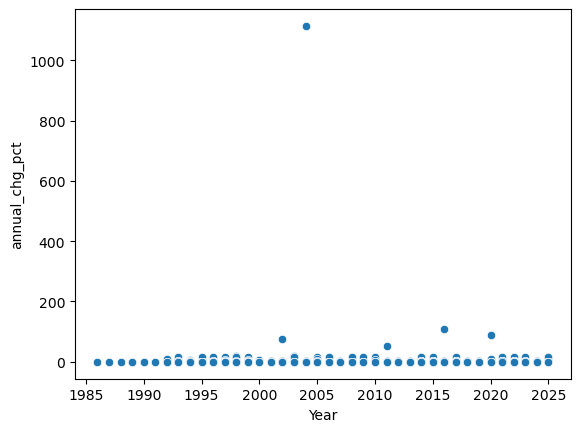

In [44]:
sns.scatterplot(data = traffic_sel, x = 'Year', y = 'annual_chg_pct')
plt.show()

#### National Park Site Area Data

In [45]:
# Load Nat'l Park Acreage Data

nps_area_file = "Data/NPS-Acreage-12-31-2025.csv"

nps_area_load = pd.read_csv(nps_area_file)

nps_area_load.head()

# Set first row to be header
nps_area_load.columns = nps_area_load.iloc[0]

nps_area_load = nps_area_load[1:].reset_index(drop = True)

nps_area_load['Gross Area Acres'] = pd.to_numeric(nps_area_load['Gross Area Acres'].str.replace(",",""))

# Remove notes from bottom of table
nps_area_load = nps_area_load.dropna(subset=['Region'])

# Downselect fields
nps_area = nps_area_load[['Area Name','Region','State','Gross Area Acres']]

# Scale area by max area value
#GAAmax = max(nps_area['Gross Area Acres'])

#nps_area['Gross Area Scaled'] = nps_area['Gross Area Acres']/GAAmax

nps_area.head(20)



,Area Name,Region,State,Gross Area Acres
0,A LINCOLN BIRTHPL NHP,1,KY,344.50
1,ACADIA NP,1,ME,49076.65
2,ADAMS NHP,1,MA,23.82
3,AFRICAN BURIAL GROUND NM,1,NY,0.35
4,AGATE FOSSIL BEDS NM,5,NE,3057.87
5,ALAGNAK WILD RVR,11,AK,30664.79
6,ALIBATES FLINT QUARRIES N,6,TX,1370.97
7,ALLEGHENY PRTGE RR NHS,1,PA,1284.27
8,AMACHE NHS,7,CO,472.59
9,AMISTAD NRA,6,TX,62945.15


In [46]:
# load area names to map to park codes for merging with other data
area_file_code = "Data/nps_area_list_codes.csv"

area_codes_load = pd.read_csv(area_file_code)
area_codes_load.head()

area_codes = area_codes_load[['Area Name','Park_Code']]

In [47]:
# attach park codes for further merging
nps_area = pd.merge(nps_area,area_codes,on = 'Area Name', how = 'left')

nps_area.head()



,Area Name,Region,State,Gross Area Acres,Park_Code
0,A LINCOLN BIRTHPL NHP,1,KY,344.50,ABLI
1,ACADIA NP,1,ME,49076.65,ACAD
2,ADAMS NHP,1,MA,23.82,ADAM
3,AFRICAN BURIAL GROUND NM,1,NY,0.35,AFBG
4,AGATE FOSSIL BEDS NM,5,NE,3057.87,AGFO


In [48]:
# remove unneeded fields
nps_area_red = nps_area[['Park_Code','Gross Area Acres']]

nps_area_red

,Park_Code,Gross Area Acres
0,ABLI,344.50
1,ACAD,49076.65
2,ADAM,23.82
3,AFBG,0.35
4,AGFO,3057.87
...,...,...
432,YELL,2219790.71
433,YOSE,761747.50
434,YUHO,195.07
435,YUCH,2526512.44


### Climate Data

In [49]:
# List of CE Regions and assigned states

cei_regions_file = "Data/CEI_Regions_States.csv"

cei_reg_load = pd.read_csv(cei_regions_file)

cei_reg_load.head(10)

,CEI Region,State,State Abb
0,Northwest,Washington,WA
1,Northwest,Oregon,OR
2,Northwest,Idaho,ID
3,West,California,CA
4,West,Nevada,NV
5,Southwest,Utah,UT
6,Southwest,Colorado,CO
7,Southwest,Arizona,AZ
8,Southwest,New Mexico,NM
9,Northern Rockies and Plains,Montana,MT


In [50]:
cei_file_us = "Data/CEI_ContigUS.csv"

cei_us_load = pd.read_csv(cei_file_us)

cei_us_load.columns = cei_us_load.iloc[0]

cei_us_load = cei_us_load.iloc[1:].reset_index(drop = False)

cei_us_load = cei_us_load.rename(columns={'Date': '','index': 'Year'})

cei_us_load['Year'] = pd.to_numeric(cei_us_load['Year'])

cei_us_load['Percentage Area'] = pd.to_numeric(cei_us_load['Percentage Area'])/100

cei_us = cei_us_load

cei_us.head(10)

Date,Year,Percentage Area
0,1910,0.2292
1,1911,0.2416
2,1912,0.3592
3,1913,0.1926
4,1914,0.1990
5,1915,0.2138
6,1916,0.2898
7,1917,0.3394
8,1918,0.1168
9,1919,0.2014


In [51]:
# Set up US value to be used for the "Multiple" region

cei_mult = cei_us
cei_mult['Region'] = 'Multiple'
cei_mult

Date,Year,Percentage Area,Region
0,1910,0.2292,Multiple
1,1911,0.2416,Multiple
2,1912,0.3592,Multiple
3,1913,0.1926,Multiple
4,1914,0.1990,Multiple
...,...,...,...
111,2021,0.3814,Multiple
112,2022,0.1758,Multiple
113,2023,0.3080,Multiple
114,2024,0.4590,Multiple


In [52]:
cei_file_1 = "Data/CEI_Northwest.csv"

reg_name = "Northwest"

cei_1_load = pd.read_csv(cei_file_1)

cei_1_load.columns = cei_1_load.iloc[0]

cei_1_load = cei_1_load.iloc[1:].reset_index(drop = False)

cei_1_load = cei_1_load.rename(columns={'Date': '','index': 'Year'})

cei_1_load['Region'] = reg_name

#cei_1_load.head(10)

cei_file_2 = "Data/CEI_Southwest.csv"

reg_name = "Southwest"

cei_2_load = pd.read_csv(cei_file_2)

cei_2_load.columns = cei_2_load.iloc[0]

cei_2_load = cei_2_load.iloc[1:].reset_index(drop = False)

cei_2_load = cei_2_load.rename(columns={'Date': '','index': 'Year'})

cei_2_load['Region'] = reg_name

#cei_2_load.head(10)

cei_file_3 = "Data/CEI_South.csv"

reg_name = "South"

cei_3_load = pd.read_csv(cei_file_3)

cei_3_load.columns = cei_3_load.iloc[0]

cei_3_load = cei_3_load.iloc[1:].reset_index(drop = False)

cei_3_load = cei_3_load.rename(columns={'Date': '','index': 'Year'})

cei_3_load['Region'] = reg_name

#cei_3_load.head(10)

cei_file_4 = "Data/CEI_Northeast.csv"

reg_name = "Northeast"

cei_4_load = pd.read_csv(cei_file_4)

cei_4_load.columns = cei_4_load.iloc[0]

cei_4_load = cei_4_load.iloc[1:].reset_index(drop = False)

cei_4_load = cei_4_load.rename(columns={'Date': '','index': 'Year'})

cei_4_load['Region'] = reg_name

#cei_4_load.head(10)

cei_file_5 = "Data/CEI_NorthernRockiesandPlains.csv"

reg_name = "Northern Rockies and Plains"

cei_5_load = pd.read_csv(cei_file_5)

cei_5_load.columns = cei_5_load.iloc[0]

cei_5_load = cei_5_load.iloc[1:].reset_index(drop = False)

cei_5_load = cei_5_load.rename(columns={'Date': '','index': 'Year'})

cei_5_load['Region'] = reg_name

#cei_5_load.head(10)

cei_file_6 = "Data/CEI_OhioValley.csv"

reg_name = "Ohio Valley"

cei_6_load = pd.read_csv(cei_file_6)

cei_6_load.columns = cei_6_load.iloc[0]

cei_6_load = cei_6_load.iloc[1:].reset_index(drop = False)

cei_6_load = cei_6_load.rename(columns={'Date': '','index': 'Year'})

cei_6_load['Region'] = reg_name

#cei_6_load.head(10)

cei_file_7 = "Data/CEI_UpperMidwest.csv"

reg_name = "Upper Midwest"

cei_7_load = pd.read_csv(cei_file_7)

cei_7_load.columns = cei_7_load.iloc[0]

cei_7_load = cei_7_load.iloc[1:].reset_index(drop = False)

cei_7_load = cei_7_load.rename(columns={'Date': '','index': 'Year'})

cei_7_load['Region'] = reg_name

#cei_7_load.head(10)

cei_file_8 = "Data/CEI_Southeast.csv"

reg_name = "Southeast"

cei_8_load = pd.read_csv(cei_file_8)

cei_8_load.columns = cei_8_load.iloc[0]

cei_8_load = cei_8_load.iloc[1:].reset_index(drop = False)

cei_8_load = cei_8_load.rename(columns={'Date': '','index': 'Year'})

cei_8_load['Region'] = reg_name

#cei_8_load.head(10)

cei_file_9 = "Data/CEI_West.csv"

reg_name = "West"

cei_9_load = pd.read_csv(cei_file_9)

cei_9_load.columns = cei_9_load.iloc[0]

cei_9_load = cei_9_load.iloc[1:].reset_index(drop = False)

cei_9_load = cei_9_load.rename(columns={'Date': '','index': 'Year'})

cei_9_load['Region'] = reg_name

#cei_9_load.head(10)

In [53]:
# Concatenate CEI Data from Tables

cei_data = pd.concat([cei_1_load,cei_2_load,cei_3_load,cei_4_load,cei_5_load,cei_6_load,cei_7_load,cei_8_load,cei_9_load, cei_mult], ignore_index=True)

cei_data['Year'] = pd.to_numeric(cei_data['Year'])
cei_data['Percentage Area'] = pd.to_numeric(cei_data['Percentage Area'])/100

cei_data.head(10)

#print(cei_data.shape)

Date,Year,Percentage Area,Region
0,1910,0.1042,Northwest
1,1911,0.3650,Northwest
2,1912,0.3418,Northwest
3,1913,0.3692,Northwest
4,1914,0.0988,Northwest
5,1915,0.0390,Northwest
6,1916,0.5424,Northwest
7,1917,0.1802,Northwest
8,1918,0.0812,Northwest
9,1919,0.4144,Northwest


In [54]:
cei_data.tail(10)

Date,Year,Percentage Area,Region
1150,2016,0.004006,Multiple
1151,2017,0.003408,Multiple
1152,2018,0.002828,Multiple
1153,2019,0.002884,Multiple
1154,2020,0.003230,Multiple
1155,2021,0.003814,Multiple
1156,2022,0.001758,Multiple
1157,2023,0.003080,Multiple
1158,2024,0.004590,Multiple
1159,2025,0.003166,Multiple


### El Nino Data

In [55]:
nino_file = "Data/ElNino_LaNina_Years_RONI.csv"

nino_load = pd.read_csv(nino_file)

In [56]:
nino_load.head()

,Year,RONI
0,1950,-1.5
1,1951,-0.5
2,1952,0.6
3,1953,0.5
4,1954,1.0


### Combine Data Sets

#### Visitor Data

In [57]:
# base data frame
visitors_sel.head()

,Park_Code,Code_Year,Year,Visitors,Visitors Scaled,annual_chg,annual_chg_pct
1,ABLI,ABLI-1980,1980,239074.0,0.010983,-32157.0,-0.118559
2,ABLI,ABLI-1981,1981,252245.0,0.011588,13171.0,0.055092
3,ABLI,ABLI-1982,1982,318707.0,0.014642,66462.0,0.263482
4,ABLI,ABLI-1983,1983,256126.0,0.011767,-62581.0,-0.196359
5,ABLI,ABLI-1984,1984,258023.0,0.011854,1897.0,0.007407


In [58]:
# join base with site designation

df = pd.merge(visitors_sel, visitor_park_wdesig, on = 'Park_Code', how = 'left')
df.head()

,Park_Code,Code_Year,Year,Visitors,Visitors Scaled,annual_chg,annual_chg_pct,Designation
0,ABLI,ABLI-1980,1980,239074.0,0.010983,-32157.0,-0.118559,National Historical Park
1,ABLI,ABLI-1981,1981,252245.0,0.011588,13171.0,0.055092,National Historical Park
2,ABLI,ABLI-1982,1982,318707.0,0.014642,66462.0,0.263482,National Historical Park
3,ABLI,ABLI-1983,1983,256126.0,0.011767,-62581.0,-0.196359,National Historical Park
4,ABLI,ABLI-1984,1984,258023.0,0.011854,1897.0,0.007407,National Historical Park


In [59]:
# join with site area

df = pd.merge(df, nps_area_red, on = 'Park_Code', how = 'left')
df.head()

,Park_Code,Code_Year,Year,Visitors,Visitors Scaled,annual_chg,annual_chg_pct,Designation,Gross Area Acres
0,ABLI,ABLI-1980,1980,239074.0,0.010983,-32157.0,-0.118559,National Historical Park,344.5
1,ABLI,ABLI-1981,1981,252245.0,0.011588,13171.0,0.055092,National Historical Park,344.5
2,ABLI,ABLI-1982,1982,318707.0,0.014642,66462.0,0.263482,National Historical Park,344.5
3,ABLI,ABLI-1983,1983,256126.0,0.011767,-62581.0,-0.196359,National Historical Park,344.5
4,ABLI,ABLI-1984,1984,258023.0,0.011854,1897.0,0.007407,National Historical Park,344.5


In [60]:
# join site info with CEI regions 
nps_sites_2 = pd.merge(nps_sites, cei_reg_load, left_on = 'State List', right_on = 'State Abb', how = 'left')

nps_sites_2.loc[nps_sites_2['State List'] == 'DC', 'CEI Region'] = 'Southeast'

# CEI Regions are only for the contiguous US. Fill in categories for AK, HI and territories
nps_sites_2.loc[nps_sites_2['State List'] == 'AK', 'CEI Region'] = 'OCONUS'
nps_sites_2.loc[nps_sites_2['State List'] == 'HI', 'CEI Region'] = 'OCONUS'
nps_sites_2.loc[nps_sites_2['State List'] == 'MP', 'CEI Region'] = 'OCONUS-T'
nps_sites_2.loc[nps_sites_2['State List'] == 'PR', 'CEI Region'] = 'OCONUS-T'
nps_sites_2.loc[nps_sites_2['State List'] == 'VI', 'CEI Region'] = 'OCONUS-T'
nps_sites_2.loc[nps_sites_2['State List'] == 'GU', 'CEI Region'] = 'OCONUS-T'
nps_sites_2.loc[nps_sites_2['State List'] == 'AS', 'CEI Region'] = 'OCONUS-T'

nps_sites_2.head()

,Site_Full_Name,Site_Name,Park_Code,Designation,State List,CEI Region,State,State Abb
0,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,ABLI,National Historical Park,KY,Ohio Valley,Kentucky,KY
1,Acadia National Park,Acadia,ACAD,National Park,ME,Northeast,Maine,ME
2,Adams National Historical Park,Adams,ADAM,National Historical Park,MA,Northeast,Massachusetts,MA
3,African Burial Ground National Monument,African Burial Ground,AFBG,National Monument,NY,Northeast,New York,NY
4,Agate Fossil Beds National Monument,Agate Fossil Beds,AGFO,National Monument,NE,Northern Rockies and Plains,Nebraska,NE


In [61]:
# extract sites with regions not defined (not contiguous US or multiple states listed)
nps_sites_2bl = nps_sites_2[nps_sites_2['CEI Region'].isna()]

nps_sites_2bl

,Site_Full_Name,Site_Name,Park_Code,Designation,State List,CEI Region,State,State Abb
19,Appalachian National Scenic Trail,Appalachian,APPA,National Scenic Trail,"CT,GA,MA,MD,ME,NC,NH,NJ,NY,PA,TN,VA,VT,WV",NaN,NaN,NaN
23,Assateague Island National Seashore,Assateague Island,ASIS,National Seashore,"MD,VA",NaN,NaN,NaN
34,Big South Fork National River & Recreation Area,Big South Fork,BISO,National River & Recreation Area,"KY,TN",NaN,NaN,NaN
36,Bighorn Canyon National Recreation Area,Bighorn Canyon,BICA,National Recreation Area,"MT,WY",NaN,NaN,NaN
40,Blackstone River Valley National Historical Park,Blackstone River Valley,BLRV,National Historical Park,"RI,MA",NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
412,Vicksburg National Military Park,Vicksburg,VICK,National Military Park,"MS,LA",NaN,NaN,NaN
419,Washington-Rochambeau Revolutionary Route Nati...,Washington-Rochambeau Revolutionary Route,WARO,National Historic Trail,"MA,RI,CT,NY,NJ,PA,DE,MD,VA,DC",NaN,NaN,NaN
433,Yellowstone National Park,Yellowstone,YELL,National Park,"ID,MT,WY",NaN,NaN,NaN
444,Chesapeake Bay,Chesapeake Bay,CBPO,Undesignated,"DC,DE,MD,NY,PA,VA,WV",NaN,NaN,NaN


In [62]:
# Tag sites with multiple states as "Multiple"
nps_sites_2bl['State'] = 'Multiple'
nps_sites_2bl['State Abb'] = 'ML'
nps_sites_2bl = nps_sites_2bl.drop(columns = ['CEI Region'])
nps_sites_2bl

,Site_Full_Name,Site_Name,Park_Code,Designation,State List,State,State Abb
19,Appalachian National Scenic Trail,Appalachian,APPA,National Scenic Trail,"CT,GA,MA,MD,ME,NC,NH,NJ,NY,PA,TN,VA,VT,WV",Multiple,ML
23,Assateague Island National Seashore,Assateague Island,ASIS,National Seashore,"MD,VA",Multiple,ML
34,Big South Fork National River & Recreation Area,Big South Fork,BISO,National River & Recreation Area,"KY,TN",Multiple,ML
36,Bighorn Canyon National Recreation Area,Bighorn Canyon,BICA,National Recreation Area,"MT,WY",Multiple,ML
40,Blackstone River Valley National Historical Park,Blackstone River Valley,BLRV,National Historical Park,"RI,MA",Multiple,ML
...,...,...,...,...,...,...,...
412,Vicksburg National Military Park,Vicksburg,VICK,National Military Park,"MS,LA",Multiple,ML
419,Washington-Rochambeau Revolutionary Route Nati...,Washington-Rochambeau Revolutionary Route,WARO,National Historic Trail,"MA,RI,CT,NY,NJ,PA,DE,MD,VA,DC",Multiple,ML
433,Yellowstone National Park,Yellowstone,YELL,National Park,"ID,MT,WY",Multiple,ML
444,Chesapeake Bay,Chesapeake Bay,CBPO,Undesignated,"DC,DE,MD,NY,PA,VA,WV",Multiple,ML


In [63]:
# Upload manually generated list to assign regions to state groups 
states_region_load = "Data/state_combo_list_key.csv"

state_region = pd.read_csv(states_region_load)

In [64]:
# join region info to site info
nps_sites_2blm = pd.merge(nps_sites_2bl, state_region, on = 'State List')

In [65]:
nps_sites_2blm

,Site_Full_Name,Site_Name,Park_Code,Designation,State List,State,State Abb,CEI Region
0,Appalachian National Scenic Trail,Appalachian,APPA,National Scenic Trail,"CT,GA,MA,MD,ME,NC,NH,NJ,NY,PA,TN,VA,VT,WV",Multiple,ML,Multiple
1,Assateague Island National Seashore,Assateague Island,ASIS,National Seashore,"MD,VA",Multiple,ML,Multiple
2,Big South Fork National River & Recreation Area,Big South Fork,BISO,National River & Recreation Area,"KY,TN",Multiple,ML,Ohio Valley
3,Bighorn Canyon National Recreation Area,Bighorn Canyon,BICA,National Recreation Area,"MT,WY",Multiple,ML,Northern Rockies and Plains
4,Blackstone River Valley National Historical Park,Blackstone River Valley,BLRV,National Historical Park,"RI,MA",Multiple,ML,Northeast
...,...,...,...,...,...,...,...,...
57,Vicksburg National Military Park,Vicksburg,VICK,National Military Park,"MS,LA",Multiple,ML,South
58,Washington-Rochambeau Revolutionary Route Nati...,Washington-Rochambeau Revolutionary Route,WARO,National Historic Trail,"MA,RI,CT,NY,NJ,PA,DE,MD,VA,DC",Multiple,ML,Multiple
59,Yellowstone National Park,Yellowstone,YELL,National Park,"ID,MT,WY",Multiple,ML,Multiple
60,Chesapeake Bay,Chesapeake Bay,CBPO,Undesignated,"DC,DE,MD,NY,PA,VA,WV",Multiple,ML,Multiple


In [66]:
# extract sites with regions defined
nps_sites_2fl = nps_sites_2[nps_sites_2['CEI Region'].notna()]

nps_sites_2fl

,Site_Full_Name,Site_Name,Park_Code,Designation,State List,CEI Region,State,State Abb
0,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,ABLI,National Historical Park,KY,Ohio Valley,Kentucky,KY
1,Acadia National Park,Acadia,ACAD,National Park,ME,Northeast,Maine,ME
2,Adams National Historical Park,Adams,ADAM,National Historical Park,MA,Northeast,Massachusetts,MA
3,African Burial Ground National Monument,African Burial Ground,AFBG,National Monument,NY,Northeast,New York,NY
4,Agate Fossil Beds National Monument,Agate Fossil Beds,AGFO,National Monument,NE,Northern Rockies and Plains,Nebraska,NE
...,...,...,...,...,...,...,...,...
469,Vietnam Veterans Memorial,Vietnam Veterans Memorial,VIVE,Undesignated,DC,Southeast,NaN,NaN
470,Washington Monument,Washington Monument,WAMO,Undesignated,DC,Southeast,NaN,NaN
471,Wolf Trap National Park for the Performing Arts,Wolf Trap National Park for the Performing Arts,WOTR,Undesignated,VA,Southeast,Virginia,VA
472,World War I Memorial,World War I Memorial,WWIM,Undesignated,DC,Southeast,NaN,NaN


In [67]:
# recombine tables to have the full set with regions defined for all sites
nps_sites_m = pd.concat([nps_sites_2fl, nps_sites_2blm], ignore_index = True)
nps_sites_m = nps_sites_m.sort_values(by = 'Park_Code')
nps_sites_m = nps_sites_m.drop(columns = ['State', 'State Abb'])
nps_sites_m

,Site_Full_Name,Site_Name,Park_Code,Designation,State List,CEI Region
0,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,ABLI,National Historical Park,KY,Ohio Valley
1,Acadia National Park,Acadia,ACAD,National Park,ME,Northeast
2,Adams National Historical Park,Adams,ADAM,National Historical Park,MA,Northeast
379,African American Civil War Memorial,African American Civil War Memorial,AFAM,Undesignated,DC,Southeast
3,African Burial Ground National Monument,African Burial Ground,AFBG,National Monument,NY,Northeast
...,...,...,...,...,...,...
374,Yorktown Battlefield Part of Colonial National...,Yorktown Battlefield,YORK,Part of Colonial National Historical Park,VA,Southeast
375,Yosemite National Park,Yosemite,YOSE,National Park,CA,West
377,Yukon - Charley Rivers National Preserve,Yukon - Charley Rivers,YUCH,National Preserve,AK,OCONUS
376,Yucca House National Monument,Yucca House,YUHO,National Monument,CO,Southwest


In [68]:
# merge data tables to create site data table for analysis
nps_next = pd.merge(df,nps_sites_m, on = 'Park_Code', how = 'left')
nps_next

,Park_Code,Code_Year,Year,Visitors,Visitors Scaled,annual_chg,annual_chg_pct,Designation_x,Gross Area Acres,Site_Full_Name,Site_Name,Designation_y,State List,CEI Region
0,ABLI,ABLI-1980,1980,239074.0,0.010983,-32157.0,-0.118559,National Historical Park,344.50,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,Ohio Valley
1,ABLI,ABLI-1981,1981,252245.0,0.011588,13171.0,0.055092,National Historical Park,344.50,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,Ohio Valley
2,ABLI,ABLI-1982,1982,318707.0,0.014642,66462.0,0.263482,National Historical Park,344.50,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,Ohio Valley
3,ABLI,ABLI-1983,1983,256126.0,0.011767,-62581.0,-0.196359,National Historical Park,344.50,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,Ohio Valley
4,ABLI,ABLI-1984,1984,258023.0,0.011854,1897.0,0.007407,National Historical Park,344.50,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,Ohio Valley
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17931,ZION,ZION-2021,2021,5039835.0,0.231534,1448581.0,0.403364,National Park,147242.66,Zion National Park,Zion,National Park,UT,Southwest
17932,ZION,ZION-2022,2022,4692417.0,0.215573,-347418.0,-0.068934,National Park,147242.66,Zion National Park,Zion,National Park,UT,Southwest
17933,ZION,ZION-2023,2023,4623238.0,0.212395,-69179.0,-0.014743,National Park,147242.66,Zion National Park,Zion,National Park,UT,Southwest
17934,ZION,ZION-2024,2024,4946592.0,0.227250,323354.0,0.069941,National Park,147242.66,Zion National Park,Zion,National Park,UT,Southwest


In [69]:
nps_sites_m

,Site_Full_Name,Site_Name,Park_Code,Designation,State List,CEI Region
0,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,ABLI,National Historical Park,KY,Ohio Valley
1,Acadia National Park,Acadia,ACAD,National Park,ME,Northeast
2,Adams National Historical Park,Adams,ADAM,National Historical Park,MA,Northeast
379,African American Civil War Memorial,African American Civil War Memorial,AFAM,Undesignated,DC,Southeast
3,African Burial Ground National Monument,African Burial Ground,AFBG,National Monument,NY,Northeast
...,...,...,...,...,...,...
374,Yorktown Battlefield Part of Colonial National...,Yorktown Battlefield,YORK,Part of Colonial National Historical Park,VA,Southeast
375,Yosemite National Park,Yosemite,YOSE,National Park,CA,West
377,Yukon - Charley Rivers National Preserve,Yukon - Charley Rivers,YUCH,National Preserve,AK,OCONUS
376,Yucca House National Monument,Yucca House,YUHO,National Monument,CO,Southwest


In [70]:
# select components 
nps_cei_regions = nps_sites_m[['Park_Code','CEI Region']]
nps_cei_regions

,Park_Code,CEI Region
0,ABLI,Ohio Valley
1,ACAD,Northeast
2,ADAM,Northeast
379,AFAM,Southeast
3,AFBG,Northeast
...,...,...
374,YORK,Southeast
375,YOSE,West
377,YUCH,OCONUS
376,YUHO,Southwest


In [71]:
# remove rows in OCONUS Regions (no CEI data)
nps_regions = nps_cei_regions[(nps_cei_regions['CEI Region']!='OCONUS') & (nps_cei_regions['CEI Region']!='OCONUS-T')  ]

nps_regions.rename(columns={"CEI Region": "Region"}, inplace=True)

nps_regions


,Park_Code,Region
0,ABLI,Ohio Valley
1,ACAD,Northeast
2,ADAM,Northeast
379,AFAM,Southeast
3,AFBG,Northeast
...,...,...
471,YELL,Multiple
374,YORK,Southeast
375,YOSE,West
376,YUHO,Southwest


In [72]:
df.shape

(17936, 9)

In [73]:
df['Park_Code'].nunique()

392

In [74]:
nps_regions['Park_Code'].nunique()

437

In [75]:
# check for common park codes between the data sets

df['Park_Code'].isin(nps_regions['Park_Code']).sum()

np.int64(16490)

In [76]:
nps_regions['Park_Code'].isin(df['Park_Code']).sum()

np.int64(362)

In [77]:
df1 = pd.merge(df, nps_regions, on = 'Park_Code', how = 'left')


In [78]:
nino_load.head()

,Year,RONI
0,1950,-1.5
1,1951,-0.5
2,1952,0.6
3,1953,0.5
4,1954,1.0


In [79]:
df1 = pd.merge(df1, nino_load, on = 'Year', how = 'left')
df1.head()

,Park_Code,Code_Year,Year,Visitors,Visitors Scaled,annual_chg,annual_chg_pct,Designation,Gross Area Acres,Region,RONI
0,ABLI,ABLI-1980,1980,239074.0,0.010983,-32157.0,-0.118559,National Historical Park,344.5,Ohio Valley,0.6
1,ABLI,ABLI-1981,1981,252245.0,0.011588,13171.0,0.055092,National Historical Park,344.5,Ohio Valley,0.0
2,ABLI,ABLI-1982,1982,318707.0,0.014642,66462.0,0.263482,National Historical Park,344.5,Ohio Valley,0.1
3,ABLI,ABLI-1983,1983,256126.0,0.011767,-62581.0,-0.196359,National Historical Park,344.5,Ohio Valley,2.5
4,ABLI,ABLI-1984,1984,258023.0,0.011854,1897.0,0.007407,National Historical Park,344.5,Ohio Valley,-0.5


In [80]:
# Add composite feature to be able to join nps data with cei data

df1['Region-Year'] = df1['Region'] + '-' + df1['Year'].astype(str)
df1.head()

,Park_Code,Code_Year,Year,Visitors,Visitors Scaled,annual_chg,annual_chg_pct,Designation,Gross Area Acres,Region,RONI,Region-Year
0,ABLI,ABLI-1980,1980,239074.0,0.010983,-32157.0,-0.118559,National Historical Park,344.5,Ohio Valley,0.6,Ohio Valley-1980
1,ABLI,ABLI-1981,1981,252245.0,0.011588,13171.0,0.055092,National Historical Park,344.5,Ohio Valley,0.0,Ohio Valley-1981
2,ABLI,ABLI-1982,1982,318707.0,0.014642,66462.0,0.263482,National Historical Park,344.5,Ohio Valley,0.1,Ohio Valley-1982
3,ABLI,ABLI-1983,1983,256126.0,0.011767,-62581.0,-0.196359,National Historical Park,344.5,Ohio Valley,2.5,Ohio Valley-1983
4,ABLI,ABLI-1984,1984,258023.0,0.011854,1897.0,0.007407,National Historical Park,344.5,Ohio Valley,-0.5,Ohio Valley-1984


In [81]:
# add same composite feature to CEI data
cei_data['Region-Year'] = cei_data['Region'] + '-' + cei_data['Year'].astype(str)
cei_data.head()


Date,Year,Percentage Area,Region,Region-Year
0,1910,0.1042,Northwest,Northwest-1910
1,1911,0.3650,Northwest,Northwest-1911
2,1912,0.3418,Northwest,Northwest-1912
3,1913,0.3692,Northwest,Northwest-1913
4,1914,0.0988,Northwest,Northwest-1914


In [82]:
df2 = pd.merge(df1, cei_data, on = 'Region-Year', how = 'left')
df2.head()

,Park_Code,Code_Year,Year_x,Visitors,Visitors Scaled,annual_chg,annual_chg_pct,Designation,Gross Area Acres,Region_x,RONI,Region-Year,Year_y,Percentage Area,Region_y
0,ABLI,ABLI-1980,1980,239074.0,0.010983,-32157.0,-0.118559,National Historical Park,344.5,Ohio Valley,0.6,Ohio Valley-1980,1980.0,0.1162,Ohio Valley
1,ABLI,ABLI-1981,1981,252245.0,0.011588,13171.0,0.055092,National Historical Park,344.5,Ohio Valley,0.0,Ohio Valley-1981,1981.0,0.1120,Ohio Valley
2,ABLI,ABLI-1982,1982,318707.0,0.014642,66462.0,0.263482,National Historical Park,344.5,Ohio Valley,0.1,Ohio Valley-1982,1982.0,0.1230,Ohio Valley
3,ABLI,ABLI-1983,1983,256126.0,0.011767,-62581.0,-0.196359,National Historical Park,344.5,Ohio Valley,2.5,Ohio Valley-1983,1983.0,0.0882,Ohio Valley
4,ABLI,ABLI-1984,1984,258023.0,0.011854,1897.0,0.007407,National Historical Park,344.5,Ohio Valley,-0.5,Ohio Valley-1984,1984.0,0.0780,Ohio Valley


In [83]:
# clean up data frame

df3 = df2[['Code_Year','Visitors','Visitors Scaled','annual_chg','annual_chg_pct','Designation','Gross Area Acres','Region_x','Percentage Area','RONI']]
df3.rename(columns={"annual_chg": "vis_annual_chg", "annual_chg_pct": "vis_annual_chg_pct", "Region_x": "Region",'Percentage Area':'cei_pct_area'}, inplace=True)
df3.head()

,Code_Year,Visitors,Visitors Scaled,vis_annual_chg,vis_annual_chg_pct,Designation,Gross Area Acres,Region,cei_pct_area,RONI
0,ABLI-1980,239074.0,0.010983,-32157.0,-0.118559,National Historical Park,344.5,Ohio Valley,0.1162,0.6
1,ABLI-1981,252245.0,0.011588,13171.0,0.055092,National Historical Park,344.5,Ohio Valley,0.1120,0.0
2,ABLI-1982,318707.0,0.014642,66462.0,0.263482,National Historical Park,344.5,Ohio Valley,0.1230,0.1
3,ABLI-1983,256126.0,0.011767,-62581.0,-0.196359,National Historical Park,344.5,Ohio Valley,0.0882,2.5
4,ABLI-1984,258023.0,0.011854,1897.0,0.007407,National Historical Park,344.5,Ohio Valley,0.0780,-0.5


In [84]:
df3.info()

<class 'pandas.DataFrame'>
RangeIndex: 17936 entries, 0 to 17935
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Code_Year           17936 non-null  str    
 1   Visitors            17936 non-null  float64
 2   Visitors Scaled     17936 non-null  float64
 3   vis_annual_chg      17936 non-null  float64
 4   vis_annual_chg_pct  17936 non-null  float64
 5   Designation         17936 non-null  str    
 6   Gross Area Acres    17936 non-null  float64
 7   Region              16490 non-null  str    
 8   cei_pct_area        16490 non-null  float64
 9   RONI                17936 non-null  float64
dtypes: float64(7), str(3)
memory usage: 2.0 MB


In [85]:
df3 = df3[df3['Region'].notna()]
df3.info()

<class 'pandas.DataFrame'>
Index: 16490 entries, 0 to 17935
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Code_Year           16490 non-null  str    
 1   Visitors            16490 non-null  float64
 2   Visitors Scaled     16490 non-null  float64
 3   vis_annual_chg      16490 non-null  float64
 4   vis_annual_chg_pct  16490 non-null  float64
 5   Designation         16490 non-null  str    
 6   Gross Area Acres    16490 non-null  float64
 7   Region              16490 non-null  str    
 8   cei_pct_area        16490 non-null  float64
 9   RONI                16490 non-null  float64
dtypes: float64(7), str(3)
memory usage: 2.0 MB


#### Traffic Data

In [86]:
# base data frame
traffic_sel.head()

,Park_Code,Code_Year,Year,Traffic Count,Traffic Count Scaled,annual_chg,annual_chg_pct
8,ABLI,ABLI-1994,1994,78659.0,0.002252,-5589.0,-0.066340
9,ABLI,ABLI-1995,1995,75253.0,0.002154,-3406.0,-0.043301
10,ABLI,ABLI-1996,1996,69894.0,0.002001,-5359.0,-0.071213
11,ABLI,ABLI-1997,1997,73586.0,0.002106,3692.0,0.052823
12,ABLI,ABLI-1998,1998,70560.0,0.002020,-3026.0,-0.041122


In [87]:
visitor_park_wdesig

,Park_Code,Designation
0,ABLI,National Historical Park
1,ACAD,National Park
2,ADAM,National Historical Park
3,AFBG,National Monument
4,AGFO,National Monument
...,...,...
395,WUPA,National Monument
396,YELL,National Park
397,YOSE,National Park
398,YUCH,National Preserve


In [88]:
# join base with site designation

df_t = pd.merge(traffic_sel, nps_sites, on = 'Park_Code', how = 'left')
df_t.head()

,Park_Code,Code_Year,Year,Traffic Count,Traffic Count Scaled,annual_chg,annual_chg_pct,Site_Full_Name,Site_Name,Designation,State List
0,ABLI,ABLI-1994,1994,78659.0,0.002252,-5589.0,-0.066340,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY
1,ABLI,ABLI-1995,1995,75253.0,0.002154,-3406.0,-0.043301,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY
2,ABLI,ABLI-1996,1996,69894.0,0.002001,-5359.0,-0.071213,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY
3,ABLI,ABLI-1997,1997,73586.0,0.002106,3692.0,0.052823,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY
4,ABLI,ABLI-1998,1998,70560.0,0.002020,-3026.0,-0.041122,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY


In [89]:
# join with site area

df_t = pd.merge(df_t, nps_area_red, on = 'Park_Code', how = 'left')
df_t.head()

,Park_Code,Code_Year,Year,Traffic Count,Traffic Count Scaled,annual_chg,annual_chg_pct,Site_Full_Name,Site_Name,Designation,State List,Gross Area Acres
0,ABLI,ABLI-1994,1994,78659.0,0.002252,-5589.0,-0.066340,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5
1,ABLI,ABLI-1995,1995,75253.0,0.002154,-3406.0,-0.043301,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5
2,ABLI,ABLI-1996,1996,69894.0,0.002001,-5359.0,-0.071213,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5
3,ABLI,ABLI-1997,1997,73586.0,0.002106,3692.0,0.052823,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5
4,ABLI,ABLI-1998,1998,70560.0,0.002020,-3026.0,-0.041122,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5


In [90]:
# merge data tables to create site data table for analysis
nps_next_t = pd.merge(df_t,nps_sites_m, on = 'Park_Code', how = 'left')
nps_next_t

,Park_Code,Code_Year,Year,Traffic Count,Traffic Count Scaled,annual_chg,annual_chg_pct,Site_Full_Name_x,Site_Name_x,Designation_x,State List_x,Gross Area Acres,Site_Full_Name_y,Site_Name_y,Designation_y,State List_y,CEI Region
0,ABLI,ABLI-1994,1994,78659.0,0.002252,-5589.0,-0.066340,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.50,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,Ohio Valley
1,ABLI,ABLI-1995,1995,75253.0,0.002154,-3406.0,-0.043301,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.50,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,Ohio Valley
2,ABLI,ABLI-1996,1996,69894.0,0.002001,-5359.0,-0.071213,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.50,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,Ohio Valley
3,ABLI,ABLI-1997,1997,73586.0,0.002106,3692.0,0.052823,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.50,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,Ohio Valley
4,ABLI,ABLI-1998,1998,70560.0,0.002020,-3026.0,-0.041122,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.50,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,Ohio Valley
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6549,ZION,ZION-2021,2021,1550770.0,0.044389,323846.0,0.263950,Zion National Park,Zion,National Park,UT,147242.66,Zion National Park,Zion,National Park,UT,Southwest
6550,ZION,ZION-2022,2022,1416308.0,0.040540,-134462.0,-0.086707,Zion National Park,Zion,National Park,UT,147242.66,Zion National Park,Zion,National Park,UT,Southwest
6551,ZION,ZION-2023,2023,1410960.0,0.040387,-5348.0,-0.003776,Zion National Park,Zion,National Park,UT,147242.66,Zion National Park,Zion,National Park,UT,Southwest
6552,ZION,ZION-2024,2024,1470401.0,0.042089,59441.0,0.042128,Zion National Park,Zion,National Park,UT,147242.66,Zion National Park,Zion,National Park,UT,Southwest


In [91]:
df1_t = pd.merge(df_t, nps_regions, on = 'Park_Code', how = 'left')

In [92]:
df1_t = pd.merge(df1_t, nino_load, on = 'Year', how = 'left')
df1_t.head()

,Park_Code,Code_Year,Year,Traffic Count,Traffic Count Scaled,annual_chg,annual_chg_pct,Site_Full_Name,Site_Name,Designation,State List,Gross Area Acres,Region,RONI
0,ABLI,ABLI-1994,1994,78659.0,0.002252,-5589.0,-0.066340,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5,Ohio Valley,0.3
1,ABLI,ABLI-1995,1995,75253.0,0.002154,-3406.0,-0.043301,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5,Ohio Valley,1.3
2,ABLI,ABLI-1996,1996,69894.0,0.002001,-5359.0,-0.071213,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5,Ohio Valley,-0.9
3,ABLI,ABLI-1997,1997,73586.0,0.002106,3692.0,0.052823,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5,Ohio Valley,-0.2
4,ABLI,ABLI-1998,1998,70560.0,0.002020,-3026.0,-0.041122,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5,Ohio Valley,2.2


In [93]:
# Add composite feature to be able to join nps data with cei data

df1_t['Region-Year'] = df1_t['Region'] + '-' + df1_t['Year'].astype(str)
df1_t.head()

,Park_Code,Code_Year,Year,Traffic Count,Traffic Count Scaled,annual_chg,annual_chg_pct,Site_Full_Name,Site_Name,Designation,State List,Gross Area Acres,Region,RONI,Region-Year
0,ABLI,ABLI-1994,1994,78659.0,0.002252,-5589.0,-0.066340,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5,Ohio Valley,0.3,Ohio Valley-1994
1,ABLI,ABLI-1995,1995,75253.0,0.002154,-3406.0,-0.043301,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5,Ohio Valley,1.3,Ohio Valley-1995
2,ABLI,ABLI-1996,1996,69894.0,0.002001,-5359.0,-0.071213,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5,Ohio Valley,-0.9,Ohio Valley-1996
3,ABLI,ABLI-1997,1997,73586.0,0.002106,3692.0,0.052823,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5,Ohio Valley,-0.2,Ohio Valley-1997
4,ABLI,ABLI-1998,1998,70560.0,0.002020,-3026.0,-0.041122,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5,Ohio Valley,2.2,Ohio Valley-1998


In [94]:
df2_t = pd.merge(df1_t, cei_data, on = 'Region-Year', how = 'left')
df2_t.head()

,Park_Code,Code_Year,Year_x,Traffic Count,Traffic Count Scaled,annual_chg,annual_chg_pct,Site_Full_Name,Site_Name,Designation,State List,Gross Area Acres,Region_x,RONI,Region-Year,Year_y,Percentage Area,Region_y
0,ABLI,ABLI-1994,1994,78659.0,0.002252,-5589.0,-0.066340,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5,Ohio Valley,0.3,Ohio Valley-1994,1994.0,0.1642,Ohio Valley
1,ABLI,ABLI-1995,1995,75253.0,0.002154,-3406.0,-0.043301,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5,Ohio Valley,1.3,Ohio Valley-1995,1995.0,0.0922,Ohio Valley
2,ABLI,ABLI-1996,1996,69894.0,0.002001,-5359.0,-0.071213,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5,Ohio Valley,-0.9,Ohio Valley-1996,1996.0,0.3412,Ohio Valley
3,ABLI,ABLI-1997,1997,73586.0,0.002106,3692.0,0.052823,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5,Ohio Valley,-0.2,Ohio Valley-1997,1997.0,0.1172,Ohio Valley
4,ABLI,ABLI-1998,1998,70560.0,0.002020,-3026.0,-0.041122,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5,Ohio Valley,2.2,Ohio Valley-1998,1998.0,0.4344,Ohio Valley


In [95]:
# clean up data frame

df3_t = df2_t[['Code_Year','Traffic Count','Traffic Count Scaled','annual_chg','annual_chg_pct','Designation','Gross Area Acres','Region_x','Percentage Area','RONI']]
df3_t.rename(columns={"annual_chg": "trf_annual_chg", "annual_chg_pct": "trf_annual_chg_pct", "Region_x": "Region",'Percentage Area':'cei_pct_area'}, inplace=True)
df3_t.head()

,Code_Year,Traffic Count,Traffic Count Scaled,trf_annual_chg,trf_annual_chg_pct,Designation,Gross Area Acres,Region,cei_pct_area,RONI
0,ABLI-1994,78659.0,0.002252,-5589.0,-0.066340,National Historical Park,344.5,Ohio Valley,0.1642,0.3
1,ABLI-1995,75253.0,0.002154,-3406.0,-0.043301,National Historical Park,344.5,Ohio Valley,0.0922,1.3
2,ABLI-1996,69894.0,0.002001,-5359.0,-0.071213,National Historical Park,344.5,Ohio Valley,0.3412,-0.9
3,ABLI-1997,73586.0,0.002106,3692.0,0.052823,National Historical Park,344.5,Ohio Valley,0.1172,-0.2
4,ABLI-1998,70560.0,0.002020,-3026.0,-0.041122,National Historical Park,344.5,Ohio Valley,0.4344,2.2


In [96]:
df3_t.info()

<class 'pandas.DataFrame'>
RangeIndex: 6554 entries, 0 to 6553
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Code_Year             6554 non-null   str    
 1   Traffic Count         6554 non-null   float64
 2   Traffic Count Scaled  6554 non-null   float64
 3   trf_annual_chg        6554 non-null   float64
 4   trf_annual_chg_pct    6554 non-null   float64
 5   Designation           6554 non-null   str    
 6   Gross Area Acres      6518 non-null   float64
 7   Region                6376 non-null   str    
 8   cei_pct_area          6376 non-null   float64
 9   RONI                  6554 non-null   float64
dtypes: float64(7), str(3)
memory usage: 752.0 KB


In [97]:
df3_t = df3_t[df3_t['Region'].notna()]
df3_t.info()

<class 'pandas.DataFrame'>
Index: 6376 entries, 0 to 6553
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Code_Year             6376 non-null   str    
 1   Traffic Count         6376 non-null   float64
 2   Traffic Count Scaled  6376 non-null   float64
 3   trf_annual_chg        6376 non-null   float64
 4   trf_annual_chg_pct    6376 non-null   float64
 5   Designation           6376 non-null   str    
 6   Gross Area Acres      6340 non-null   float64
 7   Region                6376 non-null   str    
 8   cei_pct_area          6376 non-null   float64
 9   RONI                  6376 non-null   float64
dtypes: float64(7), str(3)
memory usage: 783.1 KB


### Prepare Data for Modeling


In [98]:
df3.head()

,Code_Year,Visitors,Visitors Scaled,vis_annual_chg,vis_annual_chg_pct,Designation,Gross Area Acres,Region,cei_pct_area,RONI
0,ABLI-1980,239074.0,0.010983,-32157.0,-0.118559,National Historical Park,344.5,Ohio Valley,0.1162,0.6
1,ABLI-1981,252245.0,0.011588,13171.0,0.055092,National Historical Park,344.5,Ohio Valley,0.1120,0.0
2,ABLI-1982,318707.0,0.014642,66462.0,0.263482,National Historical Park,344.5,Ohio Valley,0.1230,0.1
3,ABLI-1983,256126.0,0.011767,-62581.0,-0.196359,National Historical Park,344.5,Ohio Valley,0.0882,2.5
4,ABLI-1984,258023.0,0.011854,1897.0,0.007407,National Historical Park,344.5,Ohio Valley,0.0780,-0.5


In [99]:
df3.describe()

,Visitors,Visitors Scaled,vis_annual_chg,vis_annual_chg_pct,Gross Area Acres,cei_pct_area,RONI
count,1.649000e+04,16490.000000,1.649000e+04,16490.000000,1.649000e+04,16490.000000,16490.000000
mean,8.241297e+05,0.037861,6.000037e+03,0.150409,1.025743e+05,0.228245,-0.021352
std,1.747376e+06,0.080276,2.715999e+05,4.122370,2.972692e+05,0.153476,1.110185
min,0.000000e+00,0.000000,-6.489533e+06,-1.000000,2.000000e-02,0.000000,-1.700000
25%,5.591450e+04,0.002569,-1.349575e+04,-0.070929,1.999600e+02,0.118400,-0.900000
50%,2.400470e+05,0.011028,7.725000e+02,0.008937,3.444320e+03,0.190000,-0.100000
75%,8.445820e+05,0.038801,2.270600e+04,0.097652,6.470122e+04,0.338800,0.600000
max,2.176718e+07,1.000000,7.100646e+06,476.542373,3.408375e+06,0.718600,2.500000


#### Visitor Data

In [100]:
df3[df3["vis_annual_chg_pct"]==0]

,Code_Year,Visitors,Visitors Scaled,vis_annual_chg,vis_annual_chg_pct,Designation,Gross Area Acres,Region,cei_pct_area,RONI


In [101]:
df3_t[df3_t["trf_annual_chg_pct"]==0]

,Code_Year,Traffic Count,Traffic Count Scaled,trf_annual_chg,trf_annual_chg_pct,Designation,Gross Area Acres,Region,cei_pct_area,RONI


In [102]:
# visitor annual change
vis_trend = [
    df3["vis_annual_chg_pct"] <= -1,
    (df3["vis_annual_chg_pct"] > -1) & (df3["vis_annual_chg_pct"] <= -0.1),
    (df3["vis_annual_chg_pct"] > -0.1) & (df3["vis_annual_chg_pct"] < 0),
     (df3["vis_annual_chg_pct"] >= 0) & (df3["vis_annual_chg_pct"] < 0.1),
    (df3["vis_annual_chg_pct"] < 1) & (df3["vis_annual_chg_pct"] >= 0.1),
    df3["vis_annual_chg_pct"] >= 1
]

# traffic annual change
trf_trend = [
    df3_t["trf_annual_chg_pct"] <= -1,
    (df3_t["trf_annual_chg_pct"] > -1) & (df3_t["trf_annual_chg_pct"] <= -0.1),
    (df3_t["trf_annual_chg_pct"] > -0.1) & (df3_t["trf_annual_chg_pct"] < 0),
     (df3_t["trf_annual_chg_pct"] >= 0) & (df3_t["trf_annual_chg_pct"] < 0.1),
    (df3_t["trf_annual_chg_pct"] < 1) & (df3_t["trf_annual_chg_pct"] >= 0.1),
    df3_t["trf_annual_chg_pct"] >= 1
]

vt_cat = ['Sig Decr','Decrease', 'Minimal Change','Minimal Change', 'Increase', 'Sig Incr']
vt_bins = [-10, -1, 0, 0, 1, 10]
vt_chg = [1, 1, 0, 0, 1, 1]
vt_updn = [0, 0, 0, 1, 1, 1]
vt_sigchg = [1, 0, 0, 0, 0, 1]


In [103]:
# Add categorial features where available

df3['Visitor Trend Cat'] = np.select(vis_trend, vt_cat, default='Minimal Change')
df3['Visitor Trend Bins'] = np.select(vis_trend, vt_bins, default=0)
df3['Visitor Trend Chg'] = np.select(vis_trend, vt_chg, default=0)
df3['Visitor Trend UpDn'] = np.select(vis_trend, vt_updn, default=0)
df3['Visitor Trend SigChg'] = np.select(vis_trend, vt_sigchg, default=0)

df3_t['Traffic Trend Cat'] = np.select(trf_trend, vt_cat, default='Minimal Change')
df3_t['Traffic Trend Bins'] = np.select(trf_trend, vt_bins, default=0)
df3_t['Traffic Trend Chg'] = np.select(trf_trend, vt_chg, default=0)
df3_t['Traffic Trend UpDn'] = np.select(trf_trend, vt_updn, default=0)
df3_t['Traffic Trend SigChg'] = np.select(trf_trend, vt_sigchg, default=0)


#### Categorization of Features

In [104]:
# Add descriptors and categories for each year based on RONI values
nino_cat = [
    df3['RONI'] >= 2,
    df3['RONI'] >= 1.5,
    df3['RONI'] >= 1.0,
    df3['RONI'] >= 0.5,
    df3['RONI'] > -0.5,
    df3['RONI'] > -1.0,
    df3['RONI'] > -1.5,
    df3['RONI'] > -2.0,
   df3['RONI'] <= -2.0,

]

nino_catt = [
    df3_t['RONI'] >= 2,
    df3_t['RONI'] >= 1.5,
    df3_t['RONI'] >= 1.0,
    df3_t['RONI'] >= 0.5,
    df3_t['RONI'] > -0.5,
    df3_t['RONI'] > -1.0,
    df3_t['RONI'] > -1.5,
    df3_t['RONI'] > -2.0,
   df3_t['RONI'] <= -2.0,

]

cat = ['El Niño','El Niño','El Niño','El Niño','Neutral','La Niña','La Niña','La Niña','La Niña']

rank = ['Very Strong','Strong','Moderate','Weak','Neutral','Weak','Moderate','Strong','Very Strong']

ranked_cat = ['Very Strong El Niño','Strong El Niño','Moderate El Niño','Weak El Niño','Neutral','Weak La Niña','Moderate La Niña','Strong La Niña','Very Strong La Niña']

df3['RONI Event'] = np.select(nino_cat,cat,default = 'Neutral')
df3['RONI Intensity'] = np.select(nino_cat,rank,default = 'Neutral')
df3['RONI Desc'] = np.select(nino_cat,ranked_cat,default = 'Neutral')

df3_t['RONI Event'] = np.select(nino_catt,cat,default = 'Neutral')
df3_t['RONI Intensity'] = np.select(nino_catt,rank,default = 'Neutral')
df3_t['RONI Desc'] = np.select(nino_catt,ranked_cat,default = 'Neutral')

#df3.head(10)

In [105]:
# Add categories for each year based on CEI values
cei_bin = [
    df3['cei_pct_area'] >= 0.4,
    df3['cei_pct_area']  > 0.2,
    df3['cei_pct_area'] <= 0.2
    ]

cei_bint = [
    df3_t['cei_pct_area'] >= 0.4,
    df3_t['cei_pct_area']  > 0.2,
    df3_t['cei_pct_area'] <= 0.2
    ]

cei_cat = ['Extreme','Increased','Nominal']

df3['CEI Cat'] = np.select(cei_bin,cei_cat,default = 'Nominal')
df3_t['CEI Cat'] = np.select(cei_bint,cei_cat,default = 'Nominal')

#df3.head(10)

In [106]:
# Add categories for each year based on CEI values
ga_bin = [
    df3['Gross Area Acres'] <= 1,
    (df3['Gross Area Acres']  > 1) & (df3['Gross Area Acres']  <= 10) ,
    (df3['Gross Area Acres']  > 10) & (df3['Gross Area Acres']  <= 100) ,
    (df3['Gross Area Acres']  > 100) & (df3['Gross Area Acres']  <= 1000) ,
    (df3['Gross Area Acres']  > 1000) & (df3['Gross Area Acres']  <= 10000) ,
    (df3['Gross Area Acres']  > 10000) & (df3['Gross Area Acres']  <= 100000) ,
    df3['Gross Area Acres'] >= 100000
    ]

ga_bint = [
    df3_t['Gross Area Acres'] <= 1,
    (df3_t['Gross Area Acres']  > 1) & (df3_t['Gross Area Acres']  <= 10) ,
    (df3_t['Gross Area Acres']  > 10) & (df3_t['Gross Area Acres']  <= 100) ,
    (df3_t['Gross Area Acres']  > 100) & (df3_t['Gross Area Acres']  <= 1000) ,
    (df3_t['Gross Area Acres']  > 1000) & (df3_t['Gross Area Acres']  <= 10000) ,
    (df3_t['Gross Area Acres']  > 10000) & (df3_t['Gross Area Acres']  <= 100000) ,
    df3_t['Gross Area Acres'] >= 100000
    ]

ga_cat = ['Tiny','Very Small','Small','Medium','Large','Very Large','Gargantuan']

df3['GAA Cat'] = np.select(ga_bin,ga_cat,default = 'Tiny')
df3_t['GAA Cat'] = np.select(ga_bint,ga_cat,default = 'Tiny')

#df3.head(10)

In [107]:
df3.head()

,Code_Year,Visitors,Visitors Scaled,vis_annual_chg,vis_annual_chg_pct,Designation,Gross Area Acres,Region,cei_pct_area,RONI,Visitor Trend Cat,Visitor Trend Bins,Visitor Trend Chg,Visitor Trend UpDn,Visitor Trend SigChg,RONI Event,RONI Intensity,RONI Desc,CEI Cat,GAA Cat
0,ABLI-1980,239074.0,0.010983,-32157.0,-0.118559,National Historical Park,344.5,Ohio Valley,0.1162,0.6,Decrease,-1,1,0,0,El Niño,Weak,Weak El Niño,Nominal,Medium
1,ABLI-1981,252245.0,0.011588,13171.0,0.055092,National Historical Park,344.5,Ohio Valley,0.1120,0.0,Minimal Change,0,0,1,0,Neutral,Neutral,Neutral,Nominal,Medium
2,ABLI-1982,318707.0,0.014642,66462.0,0.263482,National Historical Park,344.5,Ohio Valley,0.1230,0.1,Increase,1,1,1,0,Neutral,Neutral,Neutral,Nominal,Medium
3,ABLI-1983,256126.0,0.011767,-62581.0,-0.196359,National Historical Park,344.5,Ohio Valley,0.0882,2.5,Decrease,-1,1,0,0,El Niño,Very Strong,Very Strong El Niño,Nominal,Medium
4,ABLI-1984,258023.0,0.011854,1897.0,0.007407,National Historical Park,344.5,Ohio Valley,0.0780,-0.5,Minimal Change,0,0,1,0,La Niña,Weak,Weak La Niña,Nominal,Medium


In [108]:
df3_t.head()

,Code_Year,Traffic Count,Traffic Count Scaled,trf_annual_chg,trf_annual_chg_pct,Designation,Gross Area Acres,Region,cei_pct_area,RONI,Traffic Trend Cat,Traffic Trend Bins,Traffic Trend Chg,Traffic Trend UpDn,Traffic Trend SigChg,RONI Event,RONI Intensity,RONI Desc,CEI Cat,GAA Cat
0,ABLI-1994,78659.0,0.002252,-5589.0,-0.066340,National Historical Park,344.5,Ohio Valley,0.1642,0.3,Minimal Change,0,0,0,0,Neutral,Neutral,Neutral,Nominal,Medium
1,ABLI-1995,75253.0,0.002154,-3406.0,-0.043301,National Historical Park,344.5,Ohio Valley,0.0922,1.3,Minimal Change,0,0,0,0,El Niño,Moderate,Moderate El Niño,Nominal,Medium
2,ABLI-1996,69894.0,0.002001,-5359.0,-0.071213,National Historical Park,344.5,Ohio Valley,0.3412,-0.9,Minimal Change,0,0,0,0,La Niña,Weak,Weak La Niña,Increased,Medium
3,ABLI-1997,73586.0,0.002106,3692.0,0.052823,National Historical Park,344.5,Ohio Valley,0.1172,-0.2,Minimal Change,0,0,1,0,Neutral,Neutral,Neutral,Nominal,Medium
4,ABLI-1998,70560.0,0.002020,-3026.0,-0.041122,National Historical Park,344.5,Ohio Valley,0.4344,2.2,Minimal Change,0,0,0,0,El Niño,Very Strong,Very Strong El Niño,Extreme,Medium


##### Visitor Cat Numerical Transform

In [109]:
# Assign categorical features numerical representation
df3['Desig Code'] = df3['Designation'].astype('category').cat.codes 

df3["Region Code"] = df3["Region"].astype("category").cat.codes

df3["Vis Trend Code"] = df3["Visitor Trend Cat"].astype("category").cat.codes

df3["RONI Event Code"] = df3["RONI Event"].astype("category").cat.codes

df3["RONI Int Code"] = df3["RONI Intensity"].astype("category").cat.codes

df3["CEI Cat Code"] = df3["CEI Cat"].astype("category").cat.codes

df3["GAA Cat Code"] = df3["GAA Cat"].astype("category").cat.codes

display(df3)

,Code_Year,Visitors,Visitors Scaled,vis_annual_chg,vis_annual_chg_pct,Designation,Gross Area Acres,Region,cei_pct_area,RONI,...,RONI Desc,CEI Cat,GAA Cat,Desig Code,Region Code,Vis Trend Code,RONI Event Code,RONI Int Code,CEI Cat Code,GAA Cat Code
0,ABLI-1980,239074.0,0.010983,-32157.0,-0.118559,National Historical Park,344.50,Ohio Valley,0.1162,0.6,...,Weak El Niño,Nominal,Medium,8,4,0,0,4,2,2
1,ABLI-1981,252245.0,0.011588,13171.0,0.055092,National Historical Park,344.50,Ohio Valley,0.1120,0.0,...,Neutral,Nominal,Medium,8,4,2,2,1,2,2
2,ABLI-1982,318707.0,0.014642,66462.0,0.263482,National Historical Park,344.50,Ohio Valley,0.1230,0.1,...,Neutral,Nominal,Medium,8,4,1,2,1,2,2
3,ABLI-1983,256126.0,0.011767,-62581.0,-0.196359,National Historical Park,344.50,Ohio Valley,0.0882,2.5,...,Very Strong El Niño,Nominal,Medium,8,4,0,0,3,2,2
4,ABLI-1984,258023.0,0.011854,1897.0,0.007407,National Historical Park,344.50,Ohio Valley,0.0780,-0.5,...,Weak La Niña,Nominal,Medium,8,4,2,1,4,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17931,ZION-2021,5039835.0,0.231534,1448581.0,0.403364,National Park,147242.66,Southwest,0.5376,-1.2,...,Moderate La Niña,Extreme,Gargantuan,16,7,1,1,0,0,0
17932,ZION-2022,4692417.0,0.215573,-347418.0,-0.068934,National Park,147242.66,Southwest,0.1320,-1.2,...,Moderate La Niña,Nominal,Gargantuan,16,7,2,1,0,2,0
17933,ZION-2023,4623238.0,0.212395,-69179.0,-0.014743,National Park,147242.66,Southwest,0.1302,-0.8,...,Weak La Niña,Nominal,Gargantuan,16,7,2,1,4,2,0
17934,ZION-2024,4946592.0,0.227250,323354.0,0.069941,National Park,147242.66,Southwest,0.4126,1.2,...,Moderate El Niño,Extreme,Gargantuan,16,7,2,0,0,0,0


#### Traffic Transform

In [110]:
# Assign categorical features numerical representation
df3_t['Desig Code'] = df3_t['Designation'].astype('category').cat.codes 

df3_t["Region Code"] = df3_t["Region"].astype("category").cat.codes

df3_t["Vis Trend Code"] = df3_t["Traffic Trend Cat"].astype("category").cat.codes

df3_t["RONI Event Code"] = df3_t["RONI Event"].astype("category").cat.codes

df3_t["RONI Int Code"] = df3_t["RONI Intensity"].astype("category").cat.codes

df3_t["CEI Cat Code"] = df3_t["CEI Cat"].astype("category").cat.codes

df3_t["GAA Cat Code"] = df3_t["GAA Cat"].astype("category").cat.codes

display(df3_t)

,Code_Year,Traffic Count,Traffic Count Scaled,trf_annual_chg,trf_annual_chg_pct,Designation,Gross Area Acres,Region,cei_pct_area,RONI,...,RONI Desc,CEI Cat,GAA Cat,Desig Code,Region Code,Vis Trend Code,RONI Event Code,RONI Int Code,CEI Cat Code,GAA Cat Code
0,ABLI-1994,78659.0,0.002252,-5589.0,-0.066340,National Historical Park,344.50,Ohio Valley,0.1642,0.3,...,Neutral,Nominal,Medium,5,4,2,2,1,2,2
1,ABLI-1995,75253.0,0.002154,-3406.0,-0.043301,National Historical Park,344.50,Ohio Valley,0.0922,1.3,...,Moderate El Niño,Nominal,Medium,5,4,2,0,0,2,2
2,ABLI-1996,69894.0,0.002001,-5359.0,-0.071213,National Historical Park,344.50,Ohio Valley,0.3412,-0.9,...,Weak La Niña,Increased,Medium,5,4,2,1,4,1,2
3,ABLI-1997,73586.0,0.002106,3692.0,0.052823,National Historical Park,344.50,Ohio Valley,0.1172,-0.2,...,Neutral,Nominal,Medium,5,4,2,2,1,2,2
4,ABLI-1998,70560.0,0.002020,-3026.0,-0.041122,National Historical Park,344.50,Ohio Valley,0.4344,2.2,...,Very Strong El Niño,Extreme,Medium,5,4,2,0,3,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6549,ZION-2021,1550770.0,0.044389,323846.0,0.263950,National Park,147242.66,Southwest,0.5376,-1.2,...,Moderate La Niña,Extreme,Gargantuan,13,7,1,1,0,0,0
6550,ZION-2022,1416308.0,0.040540,-134462.0,-0.086707,National Park,147242.66,Southwest,0.1320,-1.2,...,Moderate La Niña,Nominal,Gargantuan,13,7,2,1,0,2,0
6551,ZION-2023,1410960.0,0.040387,-5348.0,-0.003776,National Park,147242.66,Southwest,0.1302,-0.8,...,Weak La Niña,Nominal,Gargantuan,13,7,2,1,4,2,0
6552,ZION-2024,1470401.0,0.042089,59441.0,0.042128,National Park,147242.66,Southwest,0.4126,1.2,...,Moderate El Niño,Extreme,Gargantuan,13,7,2,0,0,0,0


#### X

In [111]:
df3.to_csv('NB_data_set_vis.csv')

df3_t.to_csv('NB_data_set_trfs.csv')

### Select target parameter

In [112]:
target_v = 'Visitor Trend Bins' #'Visitor Trend UpDn' #

# Options: 'Visitor Trend Cat', 'Visitor Trend Bins', 'Visitor Trend Chg', 'Visitor Trend UpDn', 'Visitor Trend SigChg'

df3_nb = df3[[target_v, 'Region Code','Desig Code','GAA Cat Code','RONI Event Code','RONI Int Code','CEI Cat Code']]

df3_nb.to_csv('NB_data_set_sel_vis.csv')

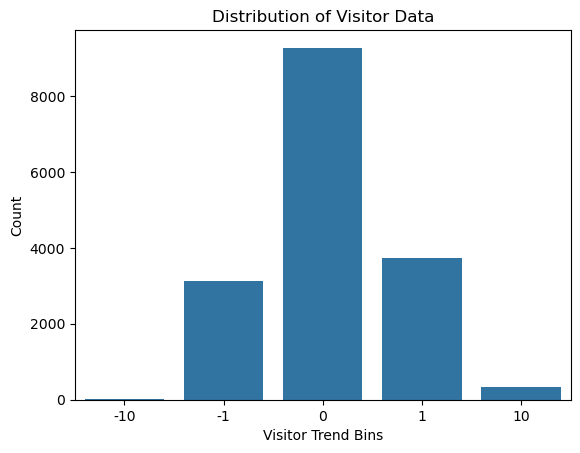

In [113]:
sns.countplot(data = df3_nb, x = target_v)
plt.title('Distribution of Visitor Data')
plt.ylabel('Count')
plt.show()

In [114]:
target_t = 'Traffic Trend Bins' #'Visitor Trend UpDn' #

# Options: 'Visitor Trend Cat', 'Visitor Trend Bins', 'Visitor Trend Chg', 'Visitor Trend UpDn', 'Visitor Trend SigChg'

df3_t_nb = df3_t[[target_t, 'Region Code','Desig Code','GAA Cat Code','RONI Event Code','RONI Int Code','CEI Cat Code']]

df3_t_nb.to_csv('NB_data_set_sel_trf.csv')

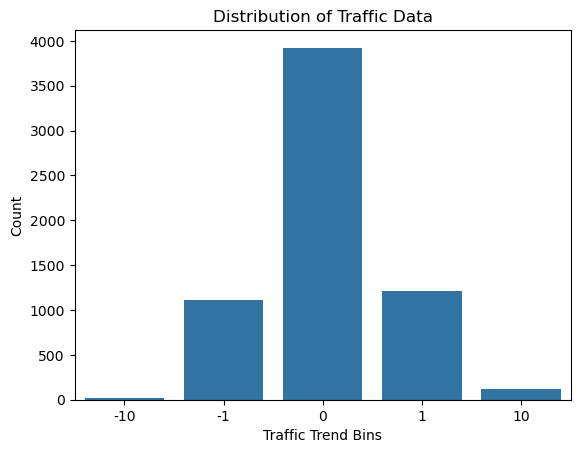

In [115]:
sns.countplot(data = df3_t_nb, x = target_t)
plt.title('Distribution of Traffic Data')
plt.ylabel('Count')
plt.show()

### Features

In [116]:
features = ['Region Code','Desig Code','GAA Cat Code','RONI Event Code','RONI Int Code','CEI Cat Code'] #'

### Visitor Data

#### Data

In [117]:
# Collinearity checks

corr_v = df3_nb[features].corr()
corr_v.style.background_gradient(cmap = 'coolwarm')

,Region Code,Desig Code,GAA Cat Code,RONI Event Code,RONI Int Code,CEI Cat Code
Region Code,1.000000,0.174987,-0.100784,0.001472,0.000844,-0.070265
Desig Code,0.174987,1.000000,0.031541,-0.001269,0.003415,0.001227
GAA Cat Code,-0.100784,0.031541,1.000000,-0.002104,-0.004376,-0.033023
RONI Event Code,0.001472,-0.001269,-0.002104,1.000000,-0.424834,0.149367
RONI Int Code,0.000844,0.003415,-0.004376,-0.424834,1.000000,0.005974
CEI Cat Code,-0.070265,0.001227,-0.033023,0.149367,0.005974,1.000000


In [118]:
# Test & training split (20/80)

Xv_train, Xv_test, yv_train, yv_test = train_test_split(df3_nb[features], df3_nb[target_v], test_size = 0.2, random_state=0)


In [119]:
# Check distribution of target counts 

# in training set
display(yv_train.value_counts())

# in est set
display(yv_test.value_counts())


Visitor Trend Bins
 0     7398
 1     3023
-1     2497
 10     256
-10      18
Name: count, dtype: int64

Visitor Trend Bins
 0     1872
 1      716
-1      637
 10      67
-10       6
Name: count, dtype: int64

In [120]:
# display the data after splitting

# Training set
display(pd.DataFrame(Xv_train).head())
display(pd.DataFrame(yv_train).head())

# Test set
display(pd.DataFrame(Xv_test).head())
display(pd.DataFrame(yv_test).head())


,Region Code,Desig Code,GAA Cat Code,RONI Event Code,RONI Int Code,CEI Cat Code
5691,7,13,2,0,0,0
7756,6,6,3,0,4,0
773,0,28,5,0,4,2
3984,2,13,1,0,0,2
7150,2,16,5,0,3,0


,Visitor Trend Bins
5691,0
7756,0
773,0
3984,0
7150,0


,Region Code,Desig Code,GAA Cat Code,RONI Event Code,RONI Int Code,CEI Cat Code
10573,2,13,2,2,1,2
14301,3,16,0,0,3,1
13186,7,16,0,1,0,2
16617,1,32,5,1,0,1
1867,5,8,2,0,4,2


,Visitor Trend Bins
10573,1
14301,1
13186,-1
16617,-1
1867,10


In [121]:
# scale data 
sc = StandardScaler()
Xv_train = sc.fit_transform(Xv_train)

In [122]:
# Visitor Training Data
display(pd.DataFrame(Xv_train).head())

,0,1,2,3,4,5
0,0.878996,-0.111152,-0.243644,-1.132805,-1.542750,-1.824975
1,0.495831,-1.018764,0.264120,-1.132805,0.989139,-1.824975
2,-1.803158,1.833732,1.279648,-1.132805,0.989139,0.838491
3,-1.036828,-0.111152,-0.751408,-1.132805,-1.542750,0.838491
4,-1.036828,0.277825,1.279648,-1.132805,0.356167,-1.824975


In [123]:
pd.DataFrame(Xv_train).to_csv('NB_data_set_trn_scale_vis.csv')

#### Visitors Classification

In [124]:
# Implementing decision tree classifier for visitors

classifier =GaussianNB()

# Visitors
classifier.fit(Xv_train, yv_train)

pred_v = classifier.predict(sc.transform(Xv_test))


Text(0.5, 1.0, 'Confusion Matrix for Naive Bayes Classifier - Visitors')

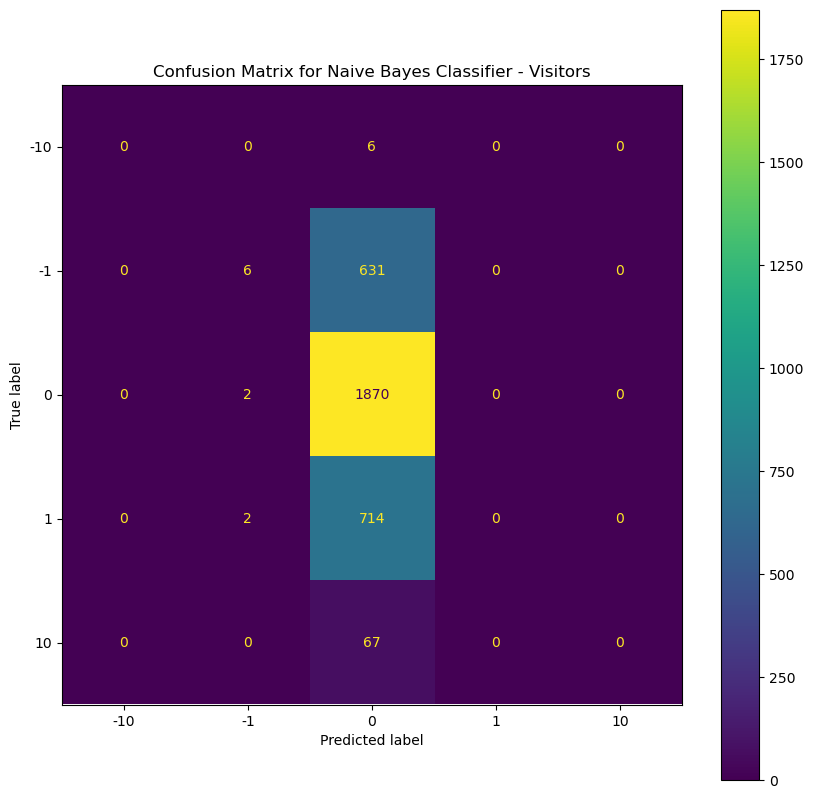

In [125]:
# Generating the confusion matrix

cm_v = confusion_matrix(yv_test, pred_v)

disp_v = ConfusionMatrixDisplay(confusion_matrix=cm_v, display_labels=classifier.classes_)

fig, ax = plt.subplots(figsize=(10,10))
disp_v.plot(ax = ax)

disp_v.ax_.set_title('Confusion Matrix for Naive Bayes Classifier - Visitors')

In [126]:
# Accuracy, F1 Score and Recall Score

accuracy_v = accuracy_score(yv_test, pred_v)
f1_v = f1_score(yv_test, pred_v, average = 'weighted')
recall_v = recall_score(yv_test, pred_v,average = 'weighted')

print(f'Accuracy: {accuracy_v}')
print(f'F1 Score: {f1_v}')
print(f'Recall Score: {recall_v}')

Accuracy: 0.5688295936931473
F1 Score: 0.4149944626730849
Recall Score: 0.5688295936931473


#### x

### Traffic Data

#### Data

In [127]:
# Collinearity checks

corr_t = df3_t_nb[features].corr()
corr_t.style.background_gradient(cmap = 'coolwarm')

,Region Code,Desig Code,GAA Cat Code,RONI Event Code,RONI Int Code,CEI Cat Code
Region Code,1.000000,0.097332,-0.002694,-0.000004,0.000735,-0.112235
Desig Code,0.097332,1.000000,0.136901,0.000554,0.007310,0.004191
GAA Cat Code,-0.002694,0.136901,1.000000,0.003182,-0.000912,-0.012179
RONI Event Code,-0.000004,0.000554,0.003182,1.000000,-0.333181,0.185145
RONI Int Code,0.000735,0.007310,-0.000912,-0.333181,1.000000,-0.006580
CEI Cat Code,-0.112235,0.004191,-0.012179,0.185145,-0.006580,1.000000


In [128]:
# Test & training split (20/80)

Xt_train, Xt_test, yt_train, yt_test = train_test_split(df3_t_nb[features], df3_t_nb[target_t], test_size = 0.2, random_state=0)


In [129]:
# Check distribution of target counts 

# in training set
display(yt_train.value_counts())

# in est set
display(yt_test.value_counts())


Traffic Trend Bins
 0     3143
 1      964
-1      890
 10      92
-10      11
Name: count, dtype: int64

Traffic Trend Bins
 0     781
 1     243
-1     224
 10     25
-10      3
Name: count, dtype: int64

In [130]:
# display the data after splitting

# Training set
display(pd.DataFrame(Xt_train).head())
display(pd.DataFrame(yt_train).head())

# Test set
display(pd.DataFrame(Xt_test).head())
display(pd.DataFrame(yt_test).head())


,Region Code,Desig Code,GAA Cat Code,RONI Event Code,RONI Int Code,CEI Cat Code
2608,2,13,0,0,4,2
534,6,16,0,1,4,1
4145,7,13,5,0,4,1
3865,3,17,0,1,0,0
152,6,4,2,1,4,1


,Traffic Trend Bins
2608,0
534,-1
4145,1
3865,0
152,1


,Region Code,Desig Code,GAA Cat Code,RONI Event Code,RONI Int Code,CEI Cat Code
3920,3,5,2,1,4,2
3090,4,10,2,1,2,1
2595,6,10,2,0,4,0
818,9,10,2,2,1,0
1189,6,17,5,1,4,1


,Traffic Trend Bins
3920,0
3090,0
2595,1
818,-1
1189,1


In [131]:
# scale data 
sc = StandardScaler()
Xt_train = sc.fit_transform(Xt_train)

In [132]:
# Traffic Training Data
display(pd.DataFrame(Xt_train).head())

,0,1,2,3,4,5
0,-1.101651,0.243627,-1.145428,-1.225212,0.977675,0.863138
1,0.435957,0.710438,-1.145428,0.282287,0.977675,-0.409485
2,0.820359,0.243627,1.468535,-1.225212,0.977675,-0.409485
3,-0.717249,0.866041,-1.145428,0.282287,-1.435462,-1.682108
4,0.435957,-1.156806,-0.099843,0.282287,0.977675,-0.409485


In [133]:
pd.DataFrame(Xt_train).to_csv('NB_data_set_trn_scale_trf.csv')

#### Traffic Classification

In [134]:
# Implementing decision tree classifier for traffic

classifier =GaussianNB()

# Visitors
classifier.fit(Xt_train, yt_train)

pred_t = classifier.predict(sc.transform(Xt_test))


Text(0.5, 1.0, 'Confusion Matrix for Naive Bayes Classifier - Traffic')

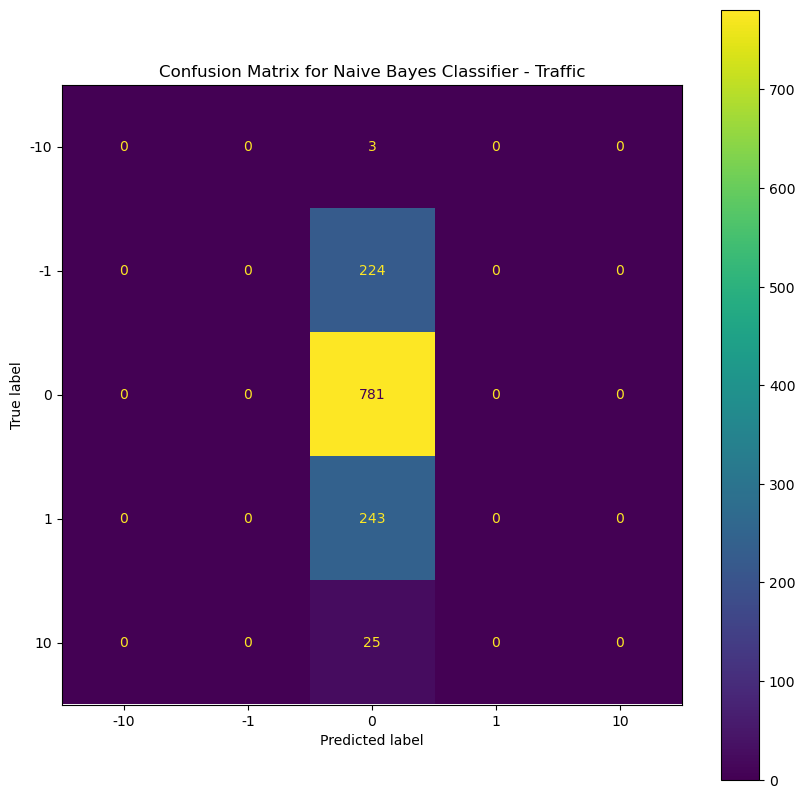

In [135]:
# Generating the confusion matrix

cm_t = confusion_matrix(yt_test, pred_t)

disp_t = ConfusionMatrixDisplay(confusion_matrix=cm_t, display_labels=classifier.classes_)

fig, ax = plt.subplots(figsize=(10,10))
disp_t.plot(ax = ax)

disp_t.ax_.set_title('Confusion Matrix for Naive Bayes Classifier - Traffic')

In [136]:
# Accuracy, F1 Score and Recall Score

accuracy_t = accuracy_score(yt_test, pred_t)
f1_t = f1_score(yt_test, pred_t, average = 'weighted')
recall_t = recall_score(yt_test, pred_t,average = 'weighted')

print(f'Accuracy: {accuracy_t}')
print(f'F1 Score: {f1_t}')
print(f'Recall Score: {recall_t}')

Accuracy: 0.6120689655172413
F1 Score: 0.4647796422644293
Recall Score: 0.6120689655172413


### x 